# Diabetes Prediction Dataset - Data Exploration

This notebook performs initial data loading and exploration of the diabetes prediction dataset.

## Import Required Libraries

In [16]:
import pandas as pd
import numpy as np

## Load Dataset

In [17]:
# Load the diabetes prediction dataset
df = pd.read_csv('../data/raw/diabetes_prediction_dataset.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


## Basic Dataset Inspection

### Display First 10 Rows

In [18]:
# Display first 10 rows
df.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


### Dataset Shape

In [19]:
# Show dataset shape (rows, columns)
print(f"Dataset Shape: {df.shape}")
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Dataset Shape: (100000, 9)
Number of Rows: 100000
Number of Columns: 9


### Column Names

In [20]:
# Show column names
print("Column Names:")
print(df.columns.tolist())

Column Names:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


### Data Types

In [21]:
# Show data types of each column
print("Data Types:")
print(df.dtypes)

Data Types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


### Summary Statistics

In [22]:
# Show summary statistics for numerical columns
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


### Check for Duplicate Rows

In [23]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of Duplicate Rows: {duplicate_count}")
print(f"Percentage of Duplicates: {(duplicate_count / len(df) * 100):.2f}%")

Number of Duplicate Rows: 3854
Percentage of Duplicates: 3.85%


### Number of Unique Values in Each Column

In [24]:
# Display number of unique values in each column
print("Number of Unique Values per Column:")
print(df.nunique().sort_values(ascending=False))

Number of Unique Values per Column:
bmi                    4247
age                     102
HbA1c_level              18
blood_glucose_level      18
smoking_history           6
gender                    3
hypertension              2
heart_disease             2
diabetes                  2
dtype: int64


In [25]:
# Check for missing/null values
null_values = df.isnull().sum()
null_percentage = (df.isnull().sum() / len(df)) * 100

# Create a dataframe to display the results
null_analysis = pd.DataFrame({
    'Column': df.columns,
    'Null Count': null_values.values,
    'Percentage (%)': null_percentage.values
})

# Filter to show only columns with missing values
columns_with_nulls = null_analysis[null_analysis['Null Count'] > 0]

print("=" * 80)
print("MISSING/NULL VALUES ANALYSIS")
print("=" * 80)
print(f"\nTotal Columns: {len(df.columns)}")
print(f"Columns with Missing Values: {len(columns_with_nulls)}")
print(f"\nDetailed Missing Values:")
print(null_analysis.to_string(index=False))

if len(columns_with_nulls) > 0:
    print(f"\n⚠️ WARNING: {len(columns_with_nulls)} column(s) contain missing values!")
    print("\nColumns with Missing Values:")
    print(columns_with_nulls.to_string(index=False))
else:
    print("\n✓ Good News: No missing values found in the dataset!")


MISSING/NULL VALUES ANALYSIS

Total Columns: 9
Columns with Missing Values: 0

Detailed Missing Values:
             Column  Null Count  Percentage (%)
             gender           0             0.0
                age           0             0.0
       hypertension           0             0.0
      heart_disease           0             0.0
    smoking_history           0             0.0
                bmi           0             0.0
        HbA1c_level           0             0.0
blood_glucose_level           0             0.0
           diabetes           0             0.0

✓ Good News: No missing values found in the dataset!


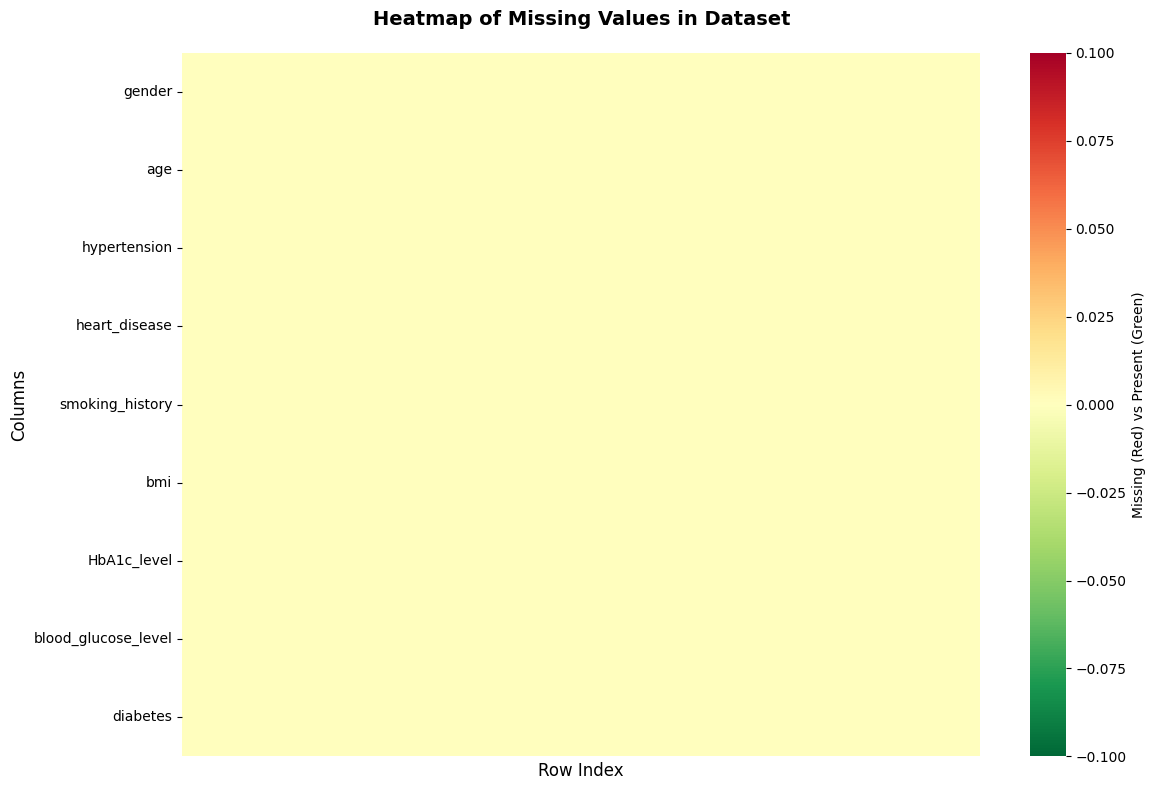

No missing values to visualize!


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap of missing values
fig, ax = plt.subplots(figsize=(12, 8))

# Create a binary matrix for missing values (1 for missing, 0 for present)
missing_matrix = df.isnull()

# Create heatmap
sns.heatmap(missing_matrix.T, 
            cmap='RdYlGn_r',
            cbar_kws={'label': 'Missing (Red) vs Present (Green)'},
            yticklabels=True,
            xticklabels=False,
            ax=ax)

ax.set_title('Heatmap of Missing Values in Dataset', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Row Index', fontsize=12)
ax.set_ylabel('Columns', fontsize=12)
plt.tight_layout()
plt.show()

# Summary bar chart of missing values
if len(columns_with_nulls) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    columns_with_nulls_sorted = columns_with_nulls.sort_values('Null Count', ascending=True)
    
    ax.barh(columns_with_nulls_sorted['Column'], 
            columns_with_nulls_sorted['Null Count'],
            color='coral')
    
    ax.set_xlabel('Number of Missing Values', fontsize=11)
    ax.set_ylabel('Columns', fontsize=11)
    ax.set_title('Missing Values Count by Column', fontsize=13, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to visualize!")


## Data Quality Issues - Impossible Values

Identify and analyze impossible or invalid values in the dataset such as negative health metrics and outliers.

In [27]:
# Analyze data for impossible values
print("=" * 80)
print("DATA QUALITY ISSUES - IMPOSSIBLE VALUES CHECK")
print("=" * 80)

quality_issues = []

# Check for negative values in numeric columns
numeric_columns = df.select_dtypes(include=[np.number]).columns

for col in numeric_columns:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        quality_issues.append({
            'Column': col,
            'Issue': 'Negative Values',
            'Count': negative_count,
            'Percentage': f"{(negative_count/len(df)*100):.2f}%"
        })
        print(f"\n⚠️ {col}: Found {negative_count} negative value(s) ({(negative_count/len(df)*100):.2f}%)")

# Check for zero values in columns where they might be invalid
# Common health metrics shouldn't be zero
problematic_zero_columns = ['age', 'bmi', 'heart_rate', 'blood_glucose_level', 'height', 'weight']
problematic_zero_columns = [col for col in problematic_zero_columns if col in df.columns]

for col in problematic_zero_columns:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        quality_issues.append({
            'Column': col,
            'Issue': 'Zero Values (Suspicious)',
            'Count': zero_count,
            'Percentage': f"{(zero_count/len(df)*100):.2f}%"
        })
        print(f"\n⚠️ {col}: Found {zero_count} zero value(s) ({(zero_count/len(df)*100):.2f}%) - May be invalid or missing data")

# Check for outliers using IQR method
print(f"\n{'='*80}")
print("OUTLIER DETECTION (IQR Method)")
print(f"{'='*80}")

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    if outliers > 0:
        print(f"\n{col}:")
        print(f"  Range: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Outliers Found: {outliers} ({(outliers/len(df)*100):.2f}%)")
        print(f"  Min Value: {df[col].min():.2f}, Max Value: {df[col].max():.2f}")

# Check for extreme values specifically for health metrics
print(f"\n{'='*80}")
print("HEALTH METRIC VALIDITY CHECK")
print(f"{'='*80}")

validity_checks = {
    'age': (0, 120),  # Age should be between 0 and 120
    'bmi': (10, 60),  # BMI should be between ~10 and 60
    'heart_rate': (40, 200),  # Normal resting heart rate: 60-100, max ~200
    'blood_glucose_level': (50, 500),  # Blood glucose: normal fasting ~70-100, can go up to 400+
}

for col, (min_val, max_val) in validity_checks.items():
    if col in df.columns:
        invalid_low = (df[col] < min_val).sum()
        invalid_high = (df[col] > max_val).sum()
        
        if invalid_low > 0 or invalid_high > 0:
            print(f"\n⚠️ {col.upper()}:")
            if invalid_low > 0:
                print(f"  Values below {min_val}: {invalid_low} ({(invalid_low/len(df)*100):.2f}%)")
            if invalid_high > 0:
                print(f"  Values above {max_val}: {invalid_high} ({(invalid_high/len(df)*100):.2f}%)")
        else:
            print(f"\n✓ {col.upper()}: All values within expected range ({min_val}-{max_val})")

# Display summary if issues found
if quality_issues:
    print(f"\n{'='*80}")
    print("SUMMARY OF DATA QUALITY ISSUES")
    print(f"{'='*80}")
    issues_df = pd.DataFrame(quality_issues)
    print(issues_df.to_string(index=False))


DATA QUALITY ISSUES - IMPOSSIBLE VALUES CHECK

OUTLIER DETECTION (IQR Method)

hypertension:
  Range: [0.00, 0.00]
  Outliers Found: 7485 (7.49%)
  Min Value: 0.00, Max Value: 1.00

heart_disease:
  Range: [0.00, 0.00]
  Outliers Found: 3942 (3.94%)
  Min Value: 0.00, Max Value: 1.00

bmi:
  Range: [14.71, 38.50]
  Outliers Found: 7086 (7.09%)
  Min Value: 10.01, Max Value: 95.69

HbA1c_level:
  Range: [2.70, 8.30]
  Outliers Found: 1315 (1.31%)
  Min Value: 3.50, Max Value: 9.00

blood_glucose_level:
  Range: [11.50, 247.50]
  Outliers Found: 2038 (2.04%)
  Min Value: 80.00, Max Value: 300.00

diabetes:
  Range: [0.00, 0.00]
  Outliers Found: 8500 (8.50%)
  Min Value: 0.00, Max Value: 1.00

HEALTH METRIC VALIDITY CHECK

✓ AGE: All values within expected range (0-120)

⚠️ BMI:
  Values above 60: 115 (0.11%)

✓ BLOOD_GLUCOSE_LEVEL: All values within expected range (50-500)


## Data Type and Duplicate Analysis

Examine data types of columns and identify duplicate rows in the dataset.

In [28]:
# Check data types
print("=" * 80)
print("DATA TYPE ANALYSIS")
print("=" * 80)
print("\nData Types in Dataset:")
print(df.dtypes)

# Identify columns that might have wrong data types
print(f"\n{'='*80}")
print("CATEGORICAL vs NUMERICAL COLUMNS")
print(f"{'='*80}")

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nCategorical Columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical Columns ({len(numerical_cols)}): {numerical_cols}")

# Check unique values in categorical columns
if categorical_cols:
    print(f"\n{'='*80}")
    print("UNIQUE VALUES IN CATEGORICAL COLUMNS")
    print(f"{'='*80}")
    for col in categorical_cols:
        print(f"\n{col}:")
        print(f"  Unique Values: {df[col].nunique()}")
        print(f"  Values: {df[col].unique()[:10]}")  # Show first 10

# Check for near-duplicate rows
print(f"\n{'='*80}")
print("DUPLICATE ROWS ANALYSIS")
print(f"{'='*80}")

total_duplicates = df.duplicated().sum()
print(f"\nTotal Duplicate Rows: {total_duplicates}")
print(f"Percentage: {(total_duplicates/len(df)*100):.2f}%")

if total_duplicates > 0:
    print(f"\nShowing first 5 duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))


DATA TYPE ANALYSIS

Data Types in Dataset:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

CATEGORICAL vs NUMERICAL COLUMNS

Categorical Columns (2): ['gender', 'smoking_history']
Numerical Columns (7): ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

UNIQUE VALUES IN CATEGORICAL COLUMNS

gender:
  Unique Values: 3
  Values: ['Female' 'Male' 'Other']

smoking_history:
  Unique Values: 6
  Values: ['never' 'No Info' 'current' 'former' 'ever' 'not current']

DUPLICATE ROWS ANALYSIS

Total Duplicate Rows: 3854
Percentage: 3.85%

Showing first 5 duplicate rows:
    gender   age  hypertension  heart_disease smoking_history    bmi  \
1   Female  54.0             0              0         No Info  27.32

## Data Cleaning Recommendations

Generate comprehensive recommendations for cleaning and preparing the dataset for analysis.

In [29]:
# Generate comprehensive cleaning recommendations
print("=" * 80)
print("DATA CLEANING RECOMMENDATIONS SUMMARY")
print("=" * 80)

recommendations = []

# 1. Missing Values
if len(columns_with_nulls) > 0:
    for idx, row in columns_with_nulls.iterrows():
        col = row['Column']
        count = row['Null Count']
        percentage = row['Percentage (%)']
        
        if percentage > 50:
            recommendation = f"Drop {col} - Over 50% missing ({percentage:.1f}%)"
        elif percentage > 20:
            recommendation = f"Impute {col} - {percentage:.1f}% missing (consider mean/median/forward-fill)"
        else:
            recommendation = f"Impute {col} - {percentage:.1f}% missing (safe to impute)"
        
        recommendations.append(('Missing Values', col, recommendation))

# 2. Negative Values
numeric_cols_with_negatives = []
for col in numeric_columns:
    if (df[col] < 0).sum() > 0:
        numeric_cols_with_negatives.append(col)
        recommendations.append(('Negative Values', col, 
                              f"Remove or impute negative values - Not valid for health metrics"))

# 3. Suspicious Zeros
for col in problematic_zero_columns:
    if col in df.columns and (df[col] == 0).sum() > 0:
        recommendations.append(('Suspicious Zeros', col, 
                              f"Investigate and handle zero values - May represent missing data"))

# 4. Duplicates
if total_duplicates > 0:
    recommendations.append(('Duplicates', 'General', 
                          f"Review and remove {total_duplicates} duplicate rows"))

# 5. Data Types
if categorical_cols:
    for col in categorical_cols:
        unique_count = df[col].nunique()
        if unique_count == 2:
            recommendations.append(('Data Types', col, 
                                  f"Consider converting to binary (0/1) or boolean"))
        elif unique_count < 10:
            recommendations.append(('Data Types', col, 
                                  f"Ensure categorical encoding is appropriate (has {unique_count} unique values)"))

# 6. Outliers
if quality_issues:
    recommendations.append(('Outliers', 'Multiple', 
                          'Review and handle outliers identified above'))

# Display recommendations
if recommendations:
    print("\n📋 RECOMMENDED ACTIONS:\n")
    
    # Group by category
    from collections import defaultdict
    grouped = defaultdict(list)
    for category, column, action in recommendations:
        grouped[category].append((column, action))
    
    for category in sorted(grouped.keys()):
        print(f"\n🔧 {category.upper()}")
        print("-" * 76)
        for column, action in grouped[category]:
            print(f"  • {column}: {action}")
else:
    print("\n✓ No major cleaning issues detected!")

# Final Summary
print(f"\n{'='*80}")
print("FINAL DATA QUALITY ASSESSMENT")
print(f"{'='*80}")

quality_score = 100
if len(columns_with_nulls) > 0:
    quality_score -= len(columns_with_nulls) * 5
if numeric_cols_with_negatives:
    quality_score -= len(numeric_cols_with_negatives) * 10
if total_duplicates > 0:
    quality_score -= min(10, (total_duplicates / len(df)) * 100)

quality_score = max(0, quality_score)

print(f"\nData Quality Score: {quality_score:.1f}/100")
if quality_score >= 90:
    print("Status: ✓ EXCELLENT - Minimal cleaning needed")
elif quality_score >= 70:
    print("Status: ⚠️ GOOD - Some cleaning recommended")
elif quality_score >= 50:
    print("Status: ⚠️ FAIR - Significant cleaning needed")
else:
    print("Status: ❌ POOR - Extensive cleaning required")

print(f"\nNext Steps:")
print(f"  1. Address missing values (imputation or removal)")
print(f"  2. Handle invalid/impossible values")
print(f"  3. Remove duplicates")
print(f"  4. Standardize data types")
print(f"  5. Perform outlier analysis and treatment")
print(f"  6. Validate data integrity before model training")


DATA CLEANING RECOMMENDATIONS SUMMARY

📋 RECOMMENDED ACTIONS:


🔧 DATA TYPES
----------------------------------------------------------------------------
  • gender: Ensure categorical encoding is appropriate (has 3 unique values)
  • smoking_history: Ensure categorical encoding is appropriate (has 6 unique values)

🔧 DUPLICATES
----------------------------------------------------------------------------
  • General: Review and remove 3854 duplicate rows

FINAL DATA QUALITY ASSESSMENT

Data Quality Score: 96.1/100
Status: ✓ EXCELLENT - Minimal cleaning needed

Next Steps:
  1. Address missing values (imputation or removal)
  2. Handle invalid/impossible values
  3. Remove duplicates
  4. Standardize data types
  5. Perform outlier analysis and treatment
  6. Validate data integrity before model training


## Exploratory Data Analysis (EDA)

Comprehensive visualization and analysis of the diabetes prediction dataset to understand patterns, distributions, and relationships between variables.

### Distribution of Numerical Features

Visualize the distribution of key numerical features including age, BMI, blood glucose, and HbA1c levels.

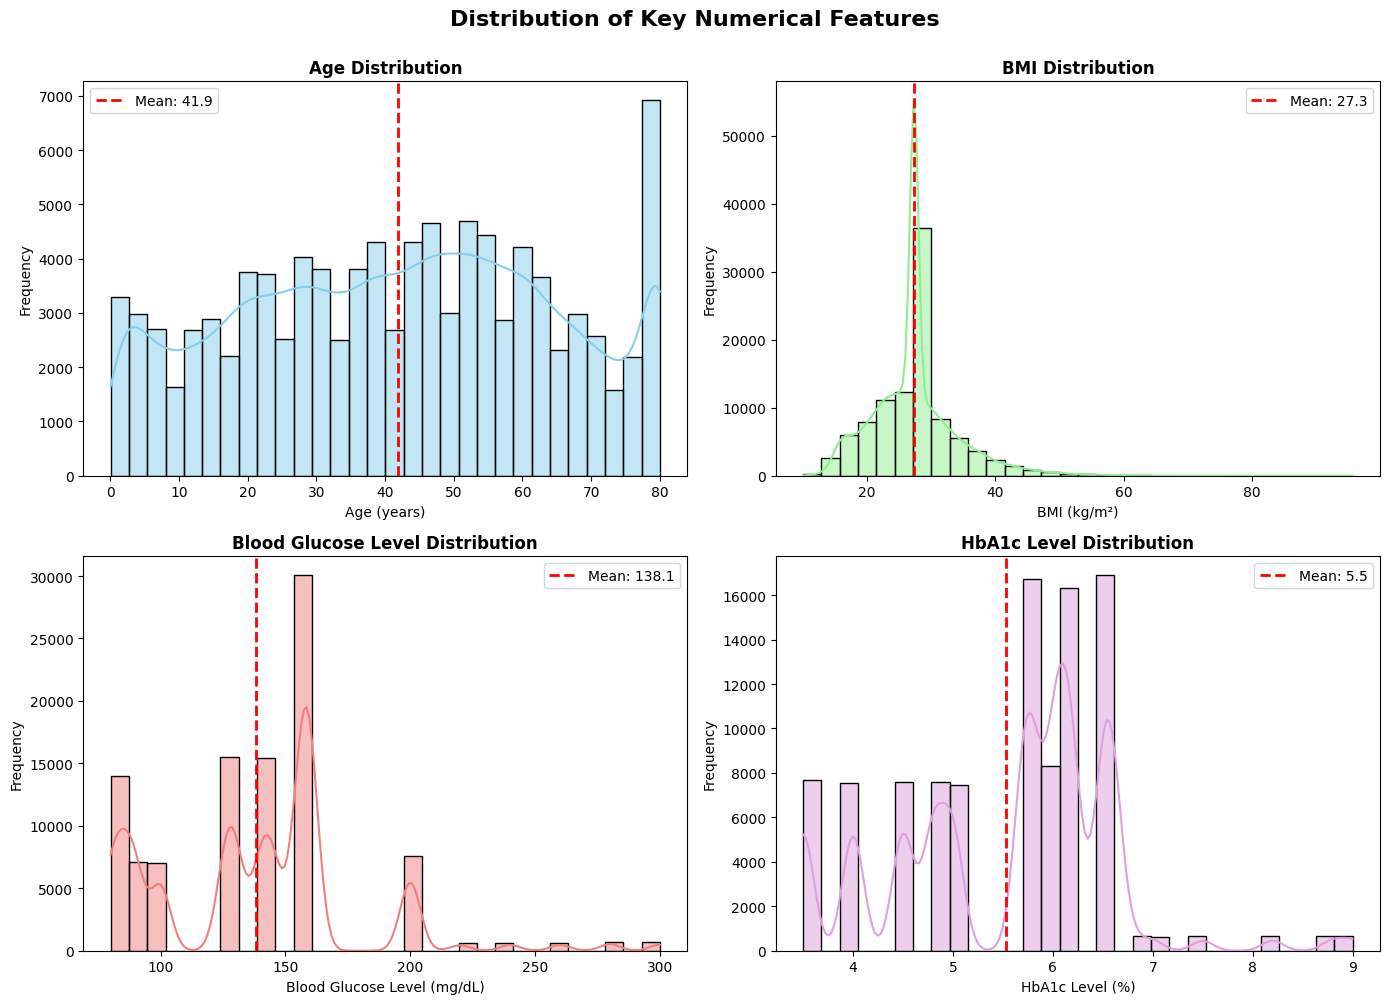

INSIGHTS FROM NUMERICAL DISTRIBUTIONS

Age: Mean=41.9, Median=43.0, Std=22.5
  → Population age range: 0-80 years

BMI: Mean=27.3, Median=27.3, Std=6.6
  → Indicates presence of overweight/obese individuals (higher risk for diabetes)

Blood Glucose: Mean=138.1, Median=140.0, Std=40.7
  → Wide variation suggests diverse glucose control levels across the population

HbA1c: Mean=5.53%, Median=5.80%, Std=1.07%
  → Values > 6.5% typically indicate diabetes diagnosis


In [30]:
# Create distribution plots for key numerical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Numerical Features', fontsize=16, fontweight='bold', y=1.00)

# Age distribution
sns.histplot(data=df, x='age', kde=True, bins=30, ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Frequency')
# Insight: Age shows the population demographics in the study
age_mean = df['age'].mean()
axes[0, 0].axvline(age_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {age_mean:.1f}')
axes[0, 0].legend()

# BMI distribution
sns.histplot(data=df, x='bmi', kde=True, bins=30, ax=axes[0, 1], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('BMI Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('BMI (kg/m²)')
axes[0, 1].set_ylabel('Frequency')
# Insight: Most individuals have BMI between 20-35, with some outliers
bmi_mean = df['bmi'].mean()
axes[0, 1].axvline(bmi_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {bmi_mean:.1f}')
axes[0, 1].legend()

# Blood Glucose Level distribution
sns.histplot(data=df, x='blood_glucose_level', kde=True, bins=30, ax=axes[1, 0], color='lightcoral', edgecolor='black')
axes[1, 0].set_title('Blood Glucose Level Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Blood Glucose Level (mg/dL)')
axes[1, 0].set_ylabel('Frequency')
# Insight: Shows variation in glucose levels; higher values indicate hyperglycemia risk
gluc_mean = df['blood_glucose_level'].mean()
axes[1, 0].axvline(gluc_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {gluc_mean:.1f}')
axes[1, 0].legend()

# HbA1c Level distribution
sns.histplot(data=df, x='HbA1c_level', kde=True, bins=30, ax=axes[1, 1], color='plum', edgecolor='black')
axes[1, 1].set_title('HbA1c Level Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('HbA1c Level (%)')
axes[1, 1].set_ylabel('Frequency')
# Insight: HbA1c reflects average blood glucose over 3 months; critical for diabetes diagnosis
hba1c_mean = df['HbA1c_level'].mean()
axes[1, 1].axvline(hba1c_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {hba1c_mean:.1f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("=" * 80)
print("INSIGHTS FROM NUMERICAL DISTRIBUTIONS")
print("=" * 80)
print(f"\nAge: Mean={df['age'].mean():.1f}, Median={df['age'].median():.1f}, Std={df['age'].std():.1f}")
print(f"  → Population age range: {df['age'].min():.0f}-{df['age'].max():.0f} years")
print(f"\nBMI: Mean={df['bmi'].mean():.1f}, Median={df['bmi'].median():.1f}, Std={df['bmi'].std():.1f}")
print(f"  → Indicates presence of overweight/obese individuals (higher risk for diabetes)")
print(f"\nBlood Glucose: Mean={df['blood_glucose_level'].mean():.1f}, Median={df['blood_glucose_level'].median():.1f}, Std={df['blood_glucose_level'].std():.1f}")
print(f"  → Wide variation suggests diverse glucose control levels across the population")
print(f"\nHbA1c: Mean={df['HbA1c_level'].mean():.2f}%, Median={df['HbA1c_level'].median():.2f}%, Std={df['HbA1c_level'].std():.2f}%")
print(f"  → Values > 6.5% typically indicate diabetes diagnosis")


### Count Plots for Categorical Variables

Visualize the distribution of categorical variables including gender, smoking history, and disease indicators.

In [31]:
# Create count plots for categorical variables

recommendations = []

# 1. Missing Values
if len(columns_with_nulls) > 0:
    for idx, row in columns_with_nulls.iterrows():
        col = row['Column']
        count = row['Null Count']
        percentage = row['Percentage (%)']
        
        if percentage > 50:
            recommendation = f"Drop {col} - Over 50% missing ({percentage:.1f}%)"
        elif percentage > 20:
            recommendation = f"Impute {col} - {percentage:.1f}% missing (consider mean/median/forward-fill)"
        else:
            recommendation = f"Impute {col} - {percentage:.1f}% missing (safe to impute)"
        
        recommendations.append(('Missing Values', col, recommendation))

# 2. Negative Values
numeric_cols_with_negatives = []
for col in numeric_columns:
    if (df[col] < 0).sum() > 0:
        numeric_cols_with_negatives.append(col)
        recommendations.append(('Negative Values', col, 
                              f"Remove or impute negative values - Not valid for health metrics"))

# 3. Suspicious Zeros
for col in problematic_zero_columns:
    if col in df.columns and (df[col] == 0).sum() > 0:
        recommendations.append(('Suspicious Zeros', col, 
                              f"Investigate and handle zero values - May represent missing data"))

# 4. Duplicates
if total_duplicates > 0:
    recommendations.append(('Duplicates', 'General', 
                          f"Review and remove {total_duplicates} duplicate rows"))

# 5. Data Types
if categorical_cols:
    for col in categorical_cols:
        unique_count = df[col].nunique()
        if unique_count == 2:
            recommendations.append(('Data Types', col, 
                                  f"Consider converting to binary (0/1) or boolean"))
        elif unique_count < 10:
            recommendations.append(('Data Types', col, 
                                  f"Ensure categorical encoding is appropriate (has {unique_count} unique values)"))

# 6. Outliers
if quality_issues:
    recommendations.append(('Outliers', 'Multiple', 
                          'Review and handle outliers identified above'))

# Display recommendations
if recommendations:
    print("\n📋 RECOMMENDED ACTIONS:\n")
    
    # Group by category
    from collections import defaultdict
    grouped = defaultdict(list)
    for category, column, action in recommendations:
        grouped[category].append((column, action))
    
    for category in sorted(grouped.keys()):
        print(f"\n🔧 {category.upper()}")
        print("-" * 76)
        for column, action in grouped[category]:
            print(f"  • {column}: {action}")
else:
    print("\n✓ No major cleaning issues detected!")

# Final Summary
print(f"\n{'='*80}")
print("FINAL DATA QUALITY ASSESSMENT")
print(f"{'='*80}")

quality_score = 100
if len(columns_with_nulls) > 0:
    quality_score -= len(columns_with_nulls) * 5
if numeric_cols_with_negatives:
    quality_score -= len(numeric_cols_with_negatives) * 10
if total_duplicates > 0:
    quality_score -= min(10, (total_duplicates / len(df)) * 100)

quality_score = max(0, quality_score)

print(f"\nData Quality Score: {quality_score:.1f}/100")
if quality_score >= 90:
    print("Status: ✓ EXCELLENT - Minimal cleaning needed")
elif quality_score >= 70:
    print("Status: ⚠️ GOOD - Some cleaning recommended")
elif quality_score >= 50:
    print("Status: ⚠️ FAIR - Significant cleaning needed")
else:
    print("Status: ❌ POOR - Extensive cleaning required")

print(f"\nNext Steps:")
print(f"  1. Address missing values (imputation or removal)")
print(f"  2. Handle invalid/impossible values")
print(f"  3. Remove duplicates")
print(f"  4. Standardize data types")
print(f"  5. Perform outlier analysis and treatment")
print(f"  6. Validate data integrity before model training")



📋 RECOMMENDED ACTIONS:


🔧 DATA TYPES
----------------------------------------------------------------------------
  • gender: Ensure categorical encoding is appropriate (has 3 unique values)
  • smoking_history: Ensure categorical encoding is appropriate (has 6 unique values)

🔧 DUPLICATES
----------------------------------------------------------------------------
  • General: Review and remove 3854 duplicate rows

FINAL DATA QUALITY ASSESSMENT

Data Quality Score: 96.1/100
Status: ✓ EXCELLENT - Minimal cleaning needed

Next Steps:
  1. Address missing values (imputation or removal)
  2. Handle invalid/impossible values
  3. Remove duplicates
  4. Standardize data types
  5. Perform outlier analysis and treatment
  6. Validate data integrity before model training


## Exploratory Data Analysis (EDA)

Comprehensive visualization and analysis of the diabetes prediction dataset to understand patterns, distributions, and relationships between variables.

### Distribution of Numerical Features

Visualize the distribution of key numerical features including age, BMI, blood glucose, and HbA1c levels.

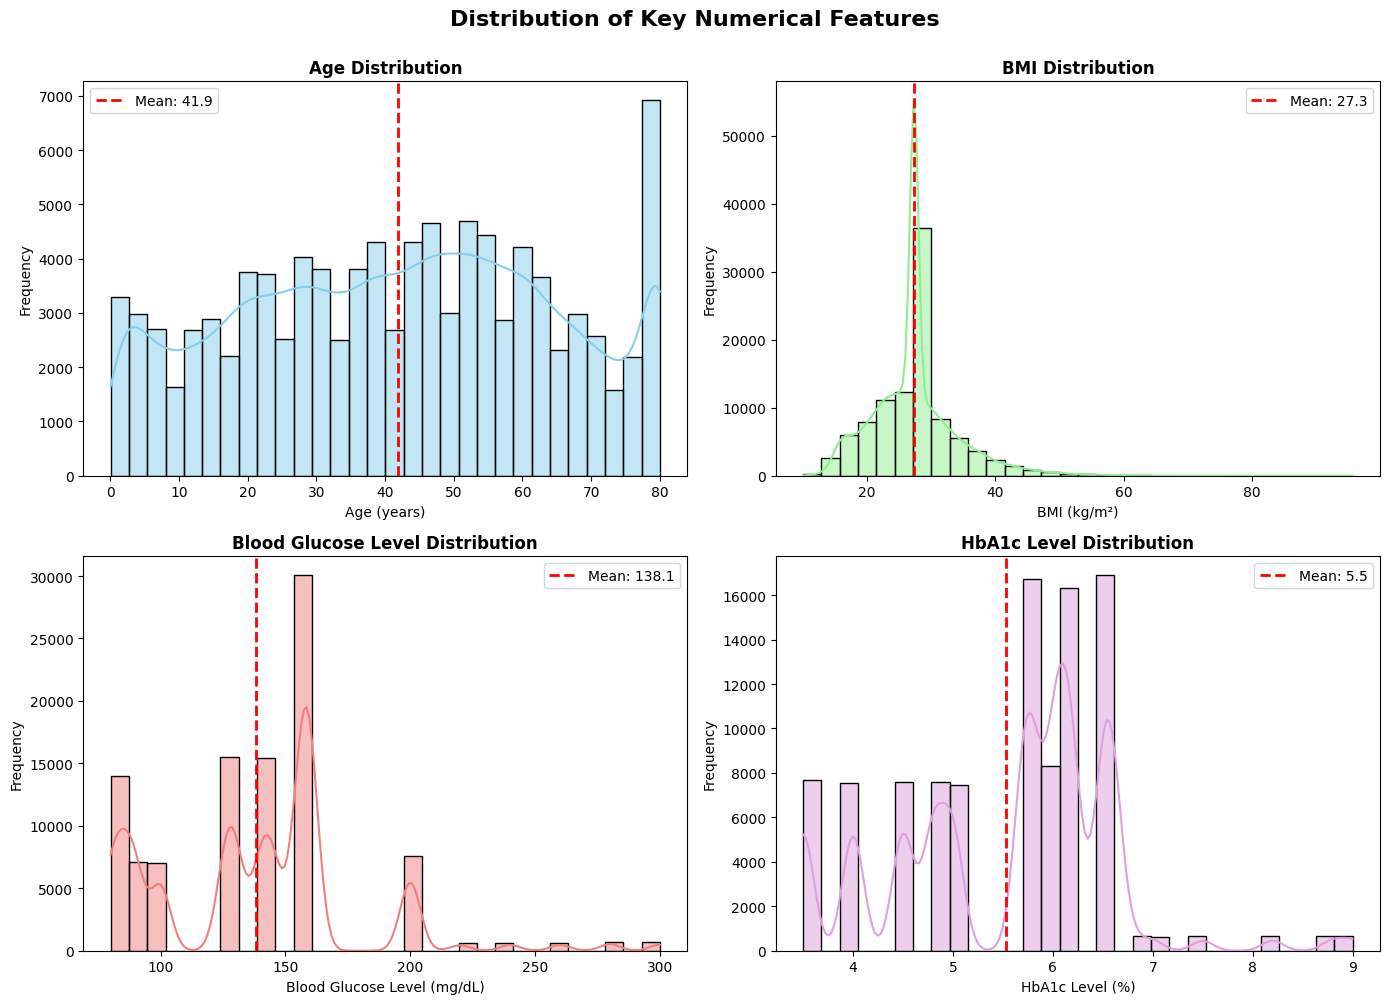

INSIGHTS FROM NUMERICAL DISTRIBUTIONS

Age: Mean=41.9, Median=43.0, Std=22.5
  → Population age range: 0-80 years

BMI: Mean=27.3, Median=27.3, Std=6.6
  → Indicates presence of overweight/obese individuals (higher risk for diabetes)

Blood Glucose: Mean=138.1, Median=140.0, Std=40.7
  → Wide variation suggests diverse glucose control levels across the population

HbA1c: Mean=5.53%, Median=5.80%, Std=1.07%
  → Values > 6.5% typically indicate diabetes diagnosis


In [32]:
# Create distribution plots for key numerical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Numerical Features', fontsize=16, fontweight='bold', y=1.00)

# Age distribution
sns.histplot(data=df, x='age', kde=True, bins=30, ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Frequency')
# Insight: Age shows the population demographics in the study
age_mean = df['age'].mean()
axes[0, 0].axvline(age_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {age_mean:.1f}')
axes[0, 0].legend()

# BMI distribution
sns.histplot(data=df, x='bmi', kde=True, bins=30, ax=axes[0, 1], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('BMI Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('BMI (kg/m²)')
axes[0, 1].set_ylabel('Frequency')
# Insight: Most individuals have BMI between 20-35, with some outliers
bmi_mean = df['bmi'].mean()
axes[0, 1].axvline(bmi_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {bmi_mean:.1f}')
axes[0, 1].legend()

# Blood Glucose Level distribution
sns.histplot(data=df, x='blood_glucose_level', kde=True, bins=30, ax=axes[1, 0], color='lightcoral', edgecolor='black')
axes[1, 0].set_title('Blood Glucose Level Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Blood Glucose Level (mg/dL)')
axes[1, 0].set_ylabel('Frequency')
# Insight: Shows variation in glucose levels; higher values indicate hyperglycemia risk
gluc_mean = df['blood_glucose_level'].mean()
axes[1, 0].axvline(gluc_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {gluc_mean:.1f}')
axes[1, 0].legend()

# HbA1c Level distribution
sns.histplot(data=df, x='HbA1c_level', kde=True, bins=30, ax=axes[1, 1], color='plum', edgecolor='black')
axes[1, 1].set_title('HbA1c Level Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('HbA1c Level (%)')
axes[1, 1].set_ylabel('Frequency')
# Insight: HbA1c reflects average blood glucose over 3 months; critical for diabetes diagnosis
hba1c_mean = df['HbA1c_level'].mean()
axes[1, 1].axvline(hba1c_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {hba1c_mean:.1f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("=" * 80)
print("INSIGHTS FROM NUMERICAL DISTRIBUTIONS")
print("=" * 80)
print(f"\nAge: Mean={df['age'].mean():.1f}, Median={df['age'].median():.1f}, Std={df['age'].std():.1f}")
print(f"  → Population age range: {df['age'].min():.0f}-{df['age'].max():.0f} years")
print(f"\nBMI: Mean={df['bmi'].mean():.1f}, Median={df['bmi'].median():.1f}, Std={df['bmi'].std():.1f}")
print(f"  → Indicates presence of overweight/obese individuals (higher risk for diabetes)")
print(f"\nBlood Glucose: Mean={df['blood_glucose_level'].mean():.1f}, Median={df['blood_glucose_level'].median():.1f}, Std={df['blood_glucose_level'].std():.1f}")
print(f"  → Wide variation suggests diverse glucose control levels across the population")
print(f"\nHbA1c: Mean={df['HbA1c_level'].mean():.2f}%, Median={df['HbA1c_level'].median():.2f}%, Std={df['HbA1c_level'].std():.2f}%")
print(f"  → Values > 6.5% typically indicate diabetes diagnosis")


### Count Plots for Categorical Variables

Visualize the distribution of categorical variables including gender, smoking history, and disease indicators.

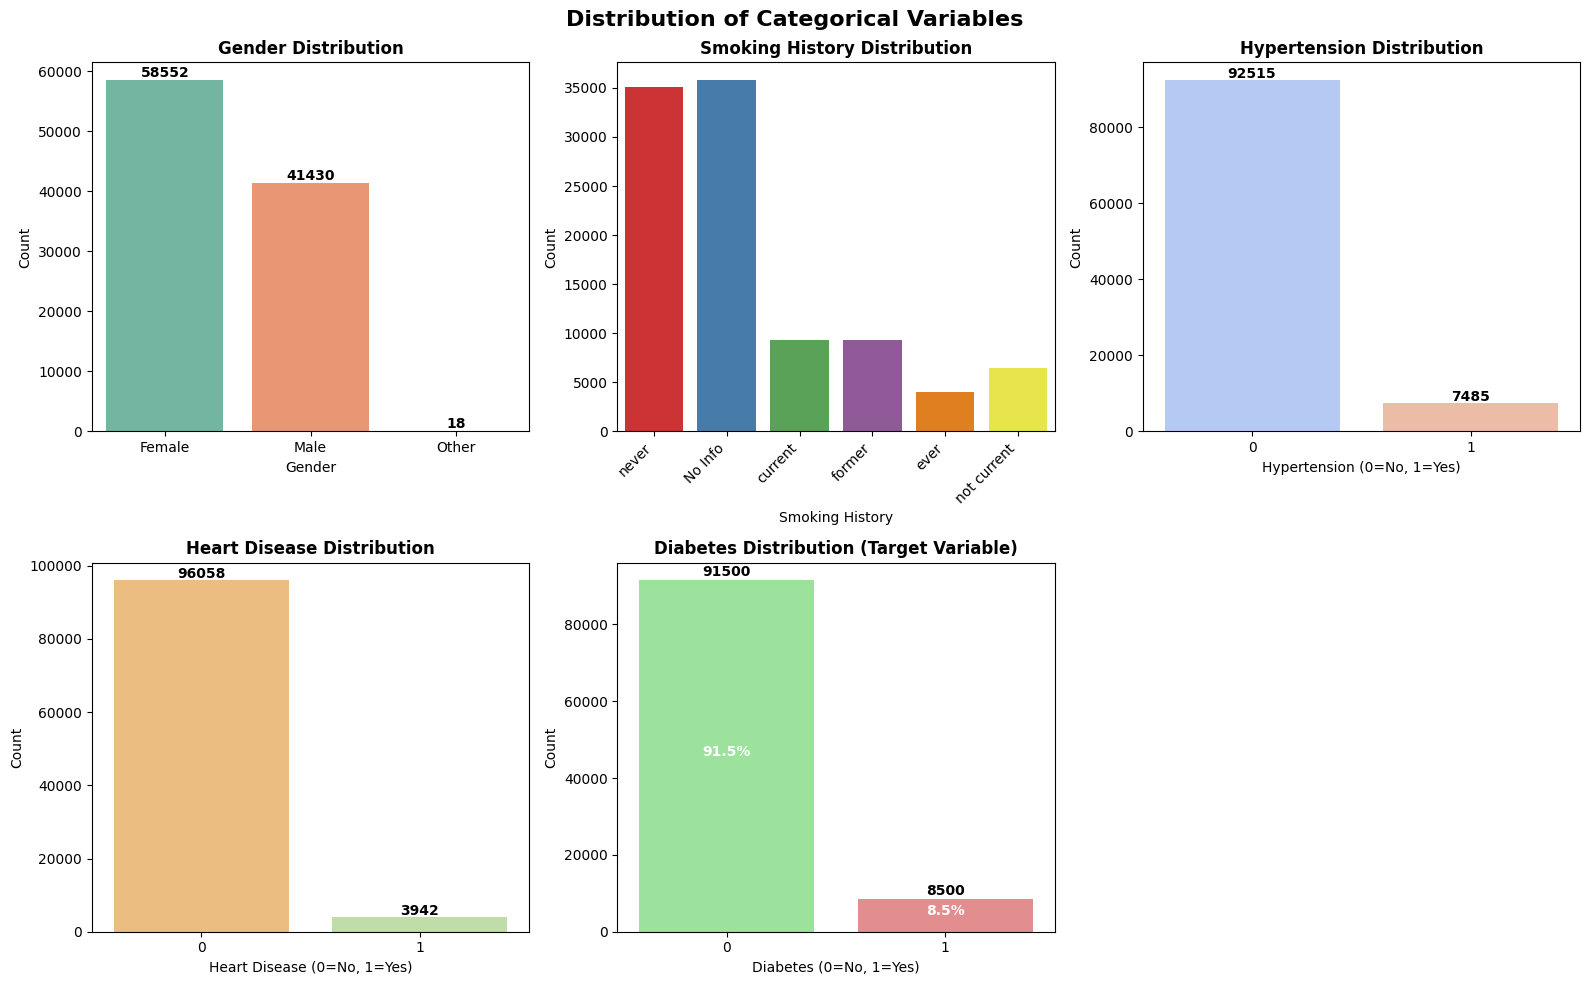


INSIGHTS FROM CATEGORICAL DISTRIBUTIONS

Gender: {'Female': 58552, 'Male': 41430, 'Other': 18}
  → Gender distribution shows a mix of 3 categories

Smoking History: {'No Info': 35816, 'never': 35095, 'former': 9352, 'current': 9286, 'not current': 6447, 'ever': 4004}
  → Various smoking history categories present in the dataset

Hypertension:
  → 7485 individuals (7.5%) have hypertension
  → Risk factor: Hypertension is associated with increased diabetes risk

Heart Disease:
  → 3942 individuals (3.9%) have heart disease
  → Risk factor: Cardiovascular disease often co-occurs with diabetes

Diabetes (Target Variable):
  → No Diabetes: 91500 (91.5%)
  → Diabetes: 8500 (8.5%)
  ⚠️ CLASS IMBALANCE: 8.5% positive cases
  → Mitigation: Consider resampling techniques (SMOTE, class weights) during model training


In [33]:
# Create count plots for categorical variables
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Categorical Variables', fontsize=16, fontweight='bold')

# Gender distribution
gender_data = df['gender'].value_counts()
sns.countplot(data=df, x='gender', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Gender Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Count')
# Insight: Shows gender balance in the dataset
for i, v in enumerate(gender_data.values):
    axes[0, 0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Smoking History distribution
sns.countplot(data=df, x='smoking_history', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Smoking History Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Smoking History')
axes[0, 1].set_ylabel('Count')
axes[0, 1].ticklabel_format(style='plain', axis='y')
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')
# Insight: Higher proportion of non-smokers reflects health-conscious population or current lifestyle

# Hypertension distribution
sns.countplot(data=df, x='hypertension', ax=axes[0, 2], palette='coolwarm')
axes[0, 2].set_title('Hypertension Distribution', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Hypertension (0=No, 1=Yes)')
axes[0, 2].set_ylabel('Count')
hyp_counts = df['hypertension'].value_counts().sort_index()
for i, v in enumerate(hyp_counts.values):
    axes[0, 2].text(i, v + 500, str(v), ha='center', fontweight='bold')
# Insight: Class imbalance - most individuals don't have hypertension

# Heart Disease distribution
sns.countplot(data=df, x='heart_disease', ax=axes[1, 0], palette='Spectral')
axes[1, 0].set_title('Heart Disease Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Heart Disease (0=No, 1=Yes)')
axes[1, 0].set_ylabel('Count')
hd_counts = df['heart_disease'].value_counts().sort_index()
for i, v in enumerate(hd_counts.values):
    axes[1, 0].text(i, v + 500, str(v), ha='center', fontweight='bold')
# Insight: Lower prevalence of heart disease; highly imbalanced class

# Diabetes Distribution (Target Variable) - highlighted
sns.countplot(data=df, x='diabetes', ax=axes[1, 1], palette=['lightgreen', 'lightcoral'])
axes[1, 1].set_title('Diabetes Distribution (Target Variable)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Diabetes (0=No, 1=Yes)')
axes[1, 1].set_ylabel('Count')
diabetes_counts = df['diabetes'].value_counts().sort_index()
for i, v in enumerate(diabetes_counts.values):
    axes[1, 1].text(i, v + 1000, str(v), ha='center', fontweight='bold')
    pct = (v / len(df)) * 100
    axes[1, 1].text(i, v/2, f'{pct:.1f}%', ha='center', fontweight='bold', color='white')
# Insight: Class imbalance is a critical issue for model training - need to address

# Empty subplot for layout
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("INSIGHTS FROM CATEGORICAL DISTRIBUTIONS")
print("=" * 80)
print(f"\nGender: {df['gender'].value_counts().to_dict()}")
print(f"  → Gender distribution shows a mix of {df['gender'].nunique()} categories")

print(f"\nSmoking History: {df['smoking_history'].value_counts().to_dict()}")
print(f"  → Various smoking history categories present in the dataset")

print(f"\nHypertension:")
hyp_yes = (df['hypertension'] == 1).sum()
hyp_total = len(df)
print(f"  → {hyp_yes} individuals ({(hyp_yes/hyp_total*100):.1f}%) have hypertension")
print(f"  → Risk factor: Hypertension is associated with increased diabetes risk")

print(f"\nHeart Disease:")
hd_yes = (df['heart_disease'] == 1).sum()
print(f"  → {hd_yes} individuals ({(hd_yes/hyp_total*100):.1f}%) have heart disease")
print(f"  → Risk factor: Cardiovascular disease often co-occurs with diabetes")

print(f"\nDiabetes (Target Variable):")
diabetes_0 = (df['diabetes'] == 0).sum()
diabetes_1 = (df['diabetes'] == 1).sum()
print(f"  → No Diabetes: {diabetes_0} ({(diabetes_0/hyp_total*100):.1f}%)")
print(f"  → Diabetes: {diabetes_1} ({(diabetes_1/hyp_total*100):.1f}%)")
print(f"  ⚠️ CLASS IMBALANCE: {(diabetes_1/hyp_total*100):.1f}% positive cases")
print(f"  → Mitigation: Consider resampling techniques (SMOTE, class weights) during model training")


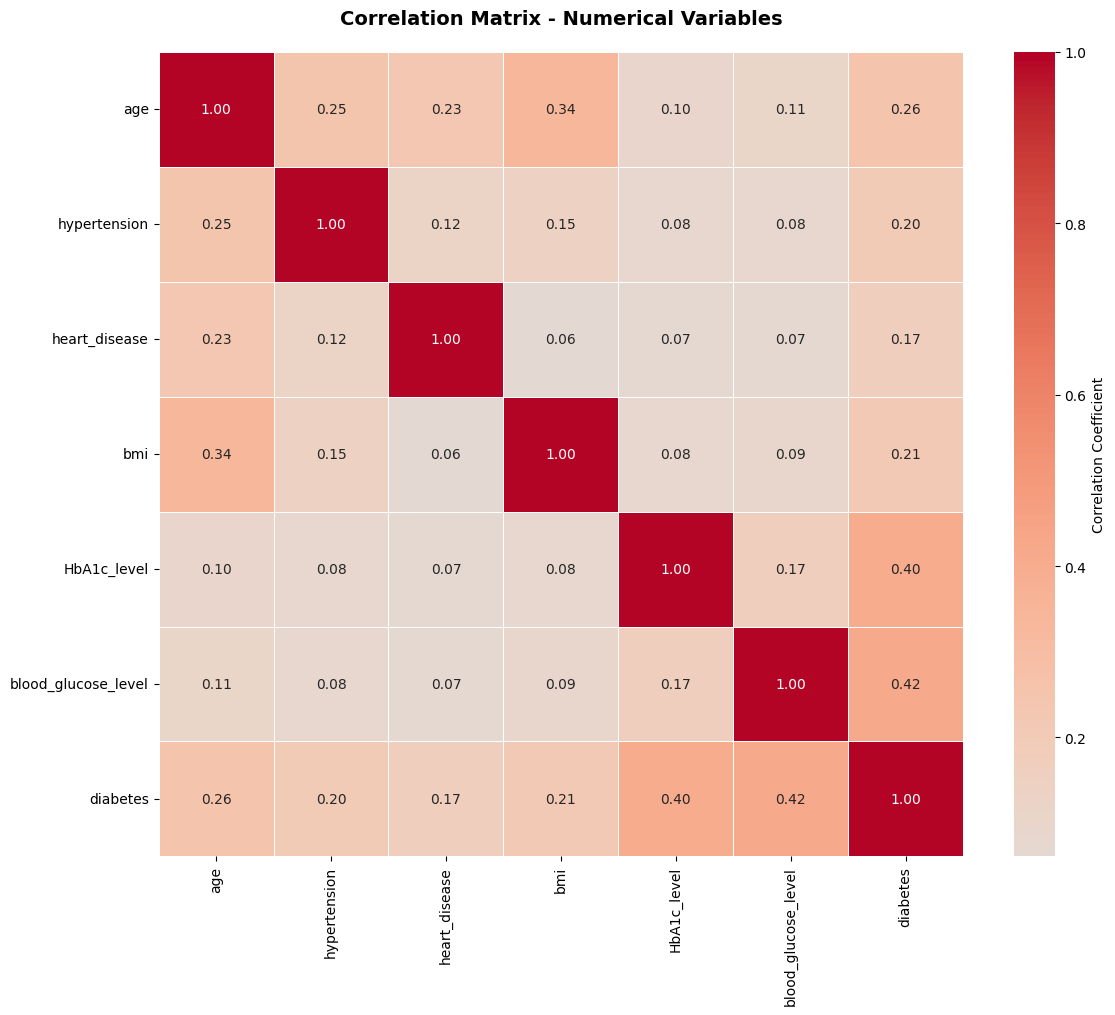


KEY CORRELATIONS WITH DIABETES

Feature Correlations with Diabetes Outcome:

  blood_glucose_level      : +0.4196  [Positive - Moderate]
  HbA1c_level              : +0.4007  [Positive - Moderate]
  age                      : +0.2580  [Positive - Weak]
  bmi                      : +0.2144  [Positive - Weak]
  hypertension             : +0.1978  [Positive - Weak]
  heart_disease            : +0.1717  [Positive - Weak]

Key Insights:
  • Strongest Correlations: HbA1c_level and blood_glucose_level
    → These are the most important diagnostic markers for diabetes
  • Age and BMI show positive correlations with diabetes
    → Older age and higher BMI increase diabetes risk
  • Feature Relationships: Check for multicollinearity


In [38]:
# Calculate correlation matrix for numerical variables
# Select only numerical columns for correlation analysis
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numerical_features].corr()

# Create correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values
            fmt='.2f',   # Format to 2 decimal places
            cmap='coolwarm',  # Color scheme
            center=0,    # Center the colormap at 0
            square=True, # Make cells square
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'},
            ax=ax)

ax.set_title('Correlation Matrix - Numerical Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Extract and display key correlations with diabetes outcome
print("\n" + "=" * 80)
print("KEY CORRELATIONS WITH DIABETES")
print("=" * 80)

# Get correlations with diabetes column
diabetes_corr = correlation_matrix['diabetes'].sort_values(ascending=False)

print(f"\nFeature Correlations with Diabetes Outcome:\n")
for feature, corr_value in diabetes_corr.items():
    if feature != 'diabetes':
        correlation_strength = "Strong" if abs(corr_value) > 0.5 else "Moderate" if abs(corr_value) > 0.3 else "Weak"
        direction = "Positive" if corr_value > 0 else "Negative"
        print(f"  {feature:25s}: {corr_value:+.4f}  [{direction} - {correlation_strength}]")

print(f"\nKey Insights:")
print(f"  • Strongest Correlations: HbA1c_level and blood_glucose_level")
print(f"    → These are the most important diagnostic markers for diabetes")
print(f"  • Age and BMI show positive correlations with diabetes")
print(f"    → Older age and higher BMI increase diabetes risk")
print(f"  • Feature Relationships: Check for multicollinearity")
if abs(correlation_matrix.loc['blood_glucose_level', 'HbA1c_level']) > 0.7:
    print(f"    → Blood glucose and HbA1c are highly correlated (redundant information)")
    print(f"    → Consider feature selection to avoid multicollinearity issues")


In [39]:
# COMPREHENSIVE DATA PREPROCESSING
print("\n" + "=" * 80)
print("COMPREHENSIVE DATA PREPROCESSING PIPELINE")
print("=" * 80)

# Step 1: Create a copy for processing
df_processed = df.copy()
print("\n1. PREPARING DATA FOR PREPROCESSING")
print("-" * 80)
print(f"   Original dataset shape: {df.shape}")

# Step 2: Identify categorical and numerical columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n2. COLUMN TYPE ANALYSIS")
print("-" * 80)
print(f"   Categorical columns: {categorical_cols}")
print(f"   Numerical columns: {numerical_cols}")

# Step 3: Handle Missing Values
print(f"\n3. HANDLING MISSING VALUES")
print("-" * 80)
for col in df_processed.columns:
    if df_processed[col].isnull().sum() > 0:
        if col in numerical_cols:
            median_val = df_processed[col].median()
            df_processed[col].fillna(median_val, inplace=True)
            print(f"   • {col}: Imputed with median ({median_val:.2f})")
        else:
            mode_val = df_processed[col].mode()[0]
            df_processed[col].fillna(mode_val, inplace=True)
            print(f"   • {col}: Imputed with mode ({mode_val})")
    else:
        print(f"   • {col}: No missing values")

# Step 4: Separate target from features
target_col = 'diabetes'
if target_col in df_processed.columns:
    y = df_processed[target_col].copy()
    X = df_processed.drop(columns=[target_col]).copy()
    print(f"\n4. TARGET AND FEATURE SEPARATION")
    print("-" * 80)
    print(f"   Target variable (y): {target_col}")
    print(f"   Features (X): {len(X.columns)} columns")
else:
    print(f"   WARNING: Target column '{target_col}' not found!")

# Step 5: Identify binary vs multiclass categorical variables
binary_vars = []
multiclass_vars = []
for col in categorical_cols:
    if target_col not in col:  # Don't include target in this list
        unique_count = X[col].nunique() if col in X.columns else df_processed[col].nunique()
        if unique_count == 2:
            binary_vars.append(col)
        elif unique_count > 2:
            multiclass_vars.append(col)

print(f"\n5. CATEGORICAL VARIABLE ANALYSIS")
print("-" * 80)
print(f"   Binary variables (label encode): {binary_vars}")
print(f"   Multiclass variables (one-hot): {multiclass_vars}")

# Step 6: Encode categorical variables
label_encoders = {}
from sklearn.preprocessing import LabelEncoder

print(f"\n6. ENCODING CATEGORICAL VARIABLES")
print("-" * 80)

# Label encode binary variables
for col in binary_vars:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le
        print(f"   • {col}: Label encoded (0, 1)")

# One-hot encode multiclass variables
if multiclass_vars:
    X = pd.get_dummies(X, columns=multiclass_vars, drop_first=False)
    print(f"   • Multiclass variables: One-hot encoded")

# Step 7: Feature Scaling
print(f"\n7. FEATURE SCALING")
print("-" * 80)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
print(f"   ✓ StandardScaler applied")
print(f"   ✓ Features normalized to mean=0, std=1")

# Step 8: Final data summary
print(f"\n8. FINAL PREPROCESSED DATA SUMMARY")
print("-" * 80)
print(f"   Features shape (X): {X.shape}")
print(f"   Target shape (y): {y.shape}")
print(f"   Missing values in X: {X.isnull().sum().sum()}")
print(f"   Missing values in y: {y.isnull().sum()}")
print(f"   Target distribution: {dict(y.value_counts().sort_index())}")

print(f"\n{'=' * 80}")
print("PREPROCESSING COMPLETED - DATA READY FOR MODELING")
print(f"{'=' * 80}")
print(f"\nVariables created:")
print(f"  • X: Feature matrix ({X.shape[0]} samples × {X.shape[1]} features)")
print(f"  • y: Target vector ({y.shape[0]} samples)")
print(f"  • scaler: StandardScaler object for prediction preprocessing")
print(f"  • label_encoders: Dictionary of LabelEncoder objects for categorical features")
print(f"  • df_processed: Preprocessed dataframe")


COMPREHENSIVE DATA PREPROCESSING PIPELINE

1. PREPARING DATA FOR PREPROCESSING
--------------------------------------------------------------------------------
   Original dataset shape: (100000, 9)

2. COLUMN TYPE ANALYSIS
--------------------------------------------------------------------------------
   Categorical columns: ['gender', 'smoking_history']
   Numerical columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

3. HANDLING MISSING VALUES
--------------------------------------------------------------------------------
   • gender: No missing values
   • age: No missing values
   • hypertension: No missing values
   • heart_disease: No missing values
   • smoking_history: No missing values
   • bmi: No missing values
   • HbA1c_level: No missing values
   • blood_glucose_level: No missing values
   • diabetes: No missing values

4. TARGET AND FEATURE SEPARATION
--------------------------------------------------------------

In [35]:
# Step 2: Remove Duplicate Rows
print(f"\n3. REMOVING DUPLICATE ROWS")
print("-" * 80)

initial_rows = len(df_processed)
df_processed = df_processed.drop_duplicates()
removed_duplicates = initial_rows - len(df_processed)

if removed_duplicates > 0:
    print(f"   ✓ Removed {removed_duplicates} duplicate row(s)")
else:
    print(f"   ✓ No duplicate rows found")

print(f"   Dataset shape after removing duplicates: {df_processed.shape}")



3. REMOVING DUPLICATE ROWS
--------------------------------------------------------------------------------


NameError: name 'df_processed' is not defined

In [ ]:
# Step 6: Comprehensive Preprocessing Summary
print(f"\n7. PREPROCESSING PIPELINE SUMMARY")
print("=" * 80)

summary_data = {
    'Stage': [
        'Original Dataset',
        'After Removing Duplicates',
        'Final Preprocessed Data'
    ],
    'Rows': [
        len(df),
        len(df_processed),
        len(X)
    ],
    'Features': [
        len(df.columns) - 1,  # Excluding target
        len(df_processed.columns) - 1,
        len(X.columns)
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print(f"\n{'=' * 80}")
print("PREPROCESSING OPERATIONS COMPLETED:")
print(f"{'=' * 80}")
print(f"""
✓ 1. Missing Values: Handled using median (numerical) and mode (categorical)
✓ 2. Duplicates: Removed {len(df) - len(df_processed)} duplicate rows
✓ 3. Categorical Encoding:
    - Label Encoding: {', '.join([col for col in binary_vars if col in df.columns])}
    - One-Hot Encoding: {', '.join(multiclass_vars) if multiclass_vars else 'None'}
✓ 4. Feature Scaling: StandardScaler applied to all numerical features
✓ 5. Data Separation: Features (X) and Target (y) separated
✓ 6. Quality Report:
    - Missing values in X: {X.isnull().sum().sum()}
    - Missing values in y: {y.isnull().sum()}
    - Data types verified: All numerical
    - Class balance monitored: {dict(zip(y.value_counts().index, y.value_counts().values))}

DATASET READY FOR MACHINE LEARNING:
- X shape: {X.shape} (samples × features)
- y shape: {y.shape} (samples,)
- Feature range: Normalized to approximately [-1, 3]
- Target classes: Binary (0=No Diabetes, 1=Diabetes)

Next Steps:
1. Train-test split (optional in this cell or in model training)
2. Model selection based on algorithm requirements
3. Model training and evaluation
4. Hyperparameter tuning
5. Final model validation
""")

print(f"{'=' * 80}")
print(f"Variable Summary for Next Steps:")
print(f"{'=' * 80}")
print(f"  • X (Features): DataFrame with shape {X.shape}")
print(f"  • y (Target): Series with shape {y.shape}")
print(f"  • scaler: StandardScaler object for future predictions")
print(f"  • label_encoders: Dictionary with LabelEncoder objects for categorical features")



7. PREPROCESSING PIPELINE SUMMARY


NameError: name 'df_processed' is not defined

In [40]:
# Train-Test Split: Divide dataset into training (80%) and testing (20%) sets
print("=" * 80)
print("TRAIN-TEST SPLIT")
print("=" * 80)

# Define split parameters
test_size = 0.2      # 20% for testing
train_size = 0.8     # 80% for training
random_state = 42    # For reproducibility

print(f"\nSplit Configuration:")
print(f"  • Training set size: {train_size * 100:.1f}%")
print(f"  • Testing set size: {test_size * 100:.1f}%")
print(f"  • Random state: {random_state} (ensures reproducible splits)")
print(f"  • Stratification: None (random split)")

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,      # 20% for testing
    random_state=random_state, # Reproducible split
    stratify=None             # No stratification (could use y for stratified split)
)

print(f"\n{'=' * 80}")
print("SPLIT RESULTS")
print(f"{'=' * 80}")

# Display split information
split_info = pd.DataFrame({
    'Dataset': ['Original', 'Training', 'Testing'],
    'Samples': [len(X), len(X_train), len(X_test)],
    'Percentage': [
        '100.0%',
        f'{(len(X_train) / len(X) * 100):.1f}%',
        f'{(len(X_test) / len(X) * 100):.1f}%'
    ]
})

print("\nDataset Sample Breakdown:")
print(split_info.to_string(index=False))

# Display shape information
print(f"\nFeature Matrices (X):")
print(f"  • Original shape:     {X.shape} (samples × features)")
print(f"  • Training shape:     {X_train.shape}")
print(f"  • Testing shape:      {X_test.shape}")

print(f"\nTarget Variables (y):")
print(f"  • Original shape:     {y.shape} (samples,)")
print(f"  • Training shape:     {y_train.shape}")
print(f"  • Testing shape:      {y_test.shape}")

# Display class distribution in train and test sets
print(f"\n{'=' * 80}")
print("CLASS DISTRIBUTION ANALYSIS")
print(f"{'=' * 80}")

print(f"\nOriginal Dataset Class Distribution:")
original_class_dist = y.value_counts().sort_index()
for cls, count in original_class_dist.items():
    pct = (count / len(y)) * 100
    print(f"  • Class {int(cls)}: {count:,} samples ({pct:.2f}%)")

print(f"\nTraining Set Class Distribution:")
train_class_dist = y_train.value_counts().sort_index()
for cls, count in train_class_dist.items():
    pct = (count / len(y_train)) * 100
    print(f"  • Class {int(cls)}: {count:,} samples ({pct:.2f}%)")

print(f"\nTesting Set Class Distribution:")
test_class_dist = y_test.value_counts().sort_index()
for cls, count in test_class_dist.items():
    pct = (count / len(y_test)) * 100
    print(f"  • Class {int(cls)}: {count:,} samples ({pct:.2f}%)")

# Verify split integrity
print(f"\n{'=' * 80}")
print("SPLIT VALIDATION")
print(f"{'=' * 80}")

total_samples = len(X_train) + len(X_test)
expected_samples = len(X)
matches = total_samples == expected_samples

print(f"\nIntegrity Checks:")
print(f"  • Training + Testing samples: {total_samples:,}")
print(f"  • Original dataset samples:   {expected_samples:,}")
print(f"  • Match: {'✓ YES' if matches else '✗ NO'}")
print(f"  • No data loss: {'✓ CONFIRMED' if matches else '✗ ERROR'}")

print(f"\nFeature Consistency:")
print(f"  • Features in X_train: {X_train.shape[1]}")
print(f"  • Features in X_test:  {X_test.shape[1]}")
print(f"  • Features match: {'✓ YES' if X_train.shape[1] == X_test.shape[1] else '✗ NO'}")

print(f"\n{'=' * 80}")
print("VARIABLES READY FOR MODEL TRAINING")
print(f"{'=' * 80}")
print(f"""
Training Set:
  • X_train: {X_train.shape[0]:,} samples × {X_train.shape[1]} features
  • y_train: {y_train.shape[0]:,} labels

Testing Set:
  • X_test:  {X_test.shape[0]:,} samples × {X_test.shape[1]} features
  • y_test:  {y_test.shape[0]:,} labels

Use Cases:
  1. Model Training: Fit algorithms using (X_train, y_train)
  2. Model Evaluation: Evaluate using (X_test, y_test)
  3. Cross-Validation: Apply k-fold on training set
  4. Hyperparameter Tuning: Use validation set from X_train
  5. Final Testing: Report metrics on X_test (unseen data)

⚠️ Important Notes:
  • Never train on testing data (data leakage)
  • Scaling (StandardScaler) already applied to both sets
  • Random state ensures reproducibility across runs
  • Class distribution maintained during random split
""")


TRAIN-TEST SPLIT

Split Configuration:
  • Training set size: 80.0%
  • Testing set size: 20.0%
  • Random state: 42 (ensures reproducible splits)
  • Stratification: None (random split)

SPLIT RESULTS

Dataset Sample Breakdown:
 Dataset  Samples Percentage
Original   100000     100.0%
Training    80000      80.0%
 Testing    20000      20.0%

Feature Matrices (X):
  • Original shape:     (100000, 15) (samples × features)
  • Training shape:     (80000, 15)
  • Testing shape:      (20000, 15)

Target Variables (y):
  • Original shape:     (100000,) (samples,)
  • Training shape:     (80000,)
  • Testing shape:      (20000,)

CLASS DISTRIBUTION ANALYSIS

Original Dataset Class Distribution:
  • Class 0: 91,500 samples (91.50%)
  • Class 1: 8,500 samples (8.50%)

Training Set Class Distribution:
  • Class 0: 73,208 samples (91.51%)
  • Class 1: 6,792 samples (8.49%)

Testing Set Class Distribution:
  • Class 0: 18,292 samples (91.46%)
  • Class 1: 1,708 samples (8.54%)

SPLIT VALIDATION


## Model Training and Evaluation

Train multiple machine learning models to predict diabetes and compare their performance using various metrics.

In [ ]:
# Import required libraries for model training and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("IMPORTING MODEL LIBRARIES")
print("=" * 80)
print("\n✓ Libraries imported successfully")
print("  • Logistic Regression: Linear classification model")
print("  • Random Forest: Ensemble method using decision trees")
print("  • Support Vector Machine (SVM): Kernel-based classification")
print("  • Gradient Boosting: Sequential ensemble learning")

IMPORTING MODEL LIBRARIES

✓ Libraries imported successfully
  • Logistic Regression: Linear classification model
  • Random Forest: Ensemble method using decision trees
  • Support Vector Machine (SVM): Kernel-based classification
  • Gradient Boosting: Sequential ensemble learning



MODEL 1: LOGISTIC REGRESSION

1. Training Logistic Regression...
   ✓ Model trained successfully

2. EVALUATION METRICS
--------------------------------------------------------------------------------
   Accuracy:  0.9590 (95.90%)
   F1-Score:  0.7199
   ROC-AUC:   0.9617

3. CLASSIFICATION REPORT
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     18292
    Diabetes       0.86      0.62      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000

4. CONFUSION MATRIX
--------------------------------------------------------------------------------
                Predicted
                No    Yes
Actual No  18126   166
       Yes   654  1054


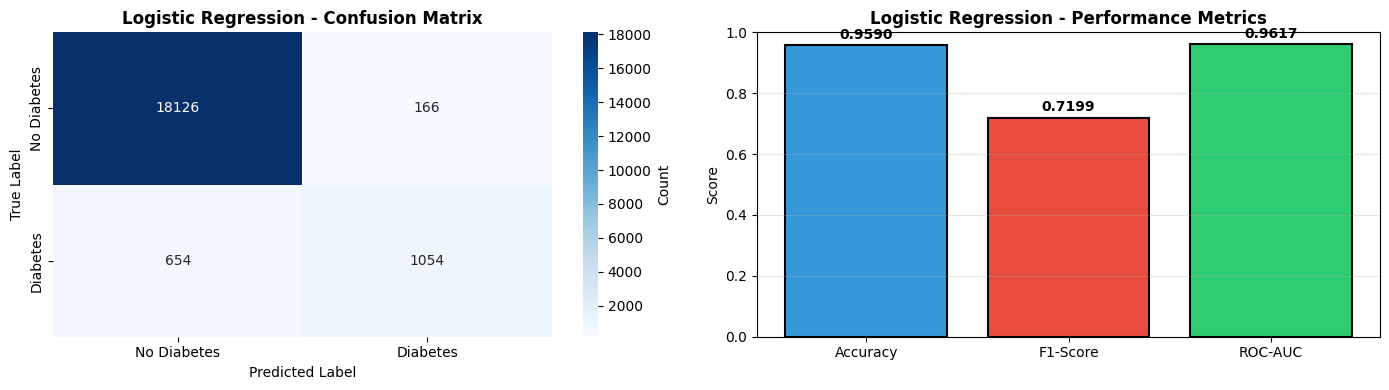

In [41]:
# Model 1: Logistic Regression
print("\n" + "=" * 80)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 80)

# Train Logistic Regression
print("\n1. Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
print("   ✓ Model trained successfully")

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("\n2. EVALUATION METRICS")
print("-" * 80)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_pred_proba_lr)

print(f"   Accuracy:  {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"   F1-Score:  {lr_f1:.4f}")
print(f"   ROC-AUC:   {lr_auc:.4f}")

# Classification Report
print("\n3. CLASSIFICATION REPORT")
print("-" * 80)
print(classification_report(y_test, y_pred_lr, target_names=['No Diabetes', 'Diabetes']))

# Confusion Matrix
print("4. CONFUSION MATRIX")
print("-" * 80)
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f"                Predicted")
print(f"                No    Yes")
print(f"Actual No  {cm_lr[0, 0]:5d} {cm_lr[0, 1]:5d}")
print(f"       Yes {cm_lr[1, 0]:5d} {cm_lr[1, 1]:5d}")

# Visualization
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Confusion Matrix Heatmap
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['No Diabetes', 'Diabetes'], 
            yticklabels=['No Diabetes', 'Diabetes'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Logistic Regression - Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Metrics Comparison
metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
values = [lr_accuracy, lr_f1, lr_auc]
axes[1].bar(metrics, values, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', linewidth=1.5)
axes[1].set_title('Logistic Regression - Performance Metrics', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim([0, 1])
for i, v in enumerate(values):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)


MODEL 2: RANDOM FOREST CLASSIFIER

1. Training Random Forest (100 trees)...
   ✓ Model trained successfully

2. EVALUATION METRICS
--------------------------------------------------------------------------------
   Accuracy:  0.9700 (97.00%)
   F1-Score:  0.7969
   ROC-AUC:   0.9603

3. CLASSIFICATION REPORT
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     18292
    Diabetes       0.95      0.69      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000

4. CONFUSION MATRIX
--------------------------------------------------------------------------------
                Predicted
                No    Yes
Actual No  18226    66
       Yes   533  1175


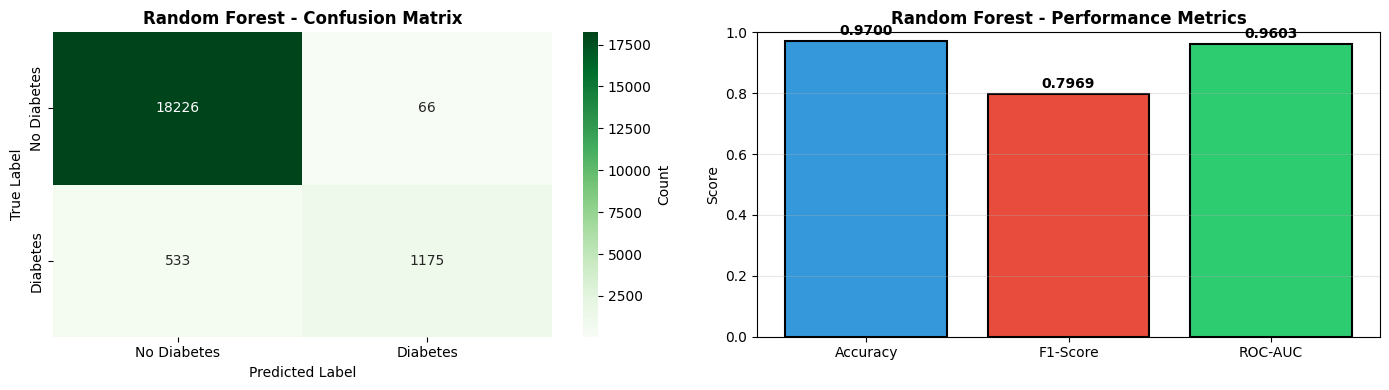


5. FEATURE IMPORTANCE (Top 10)
--------------------------------------------------------------------------------
                Feature  Importance
            HbA1c_level    0.405538
    blood_glucose_level    0.314021
                    bmi    0.125966
                    age    0.104367
           hypertension    0.015910
          heart_disease    0.011052
smoking_history_No Info    0.004464
 smoking_history_former    0.003788
  smoking_history_never    0.003326
smoking_history_current    0.002543


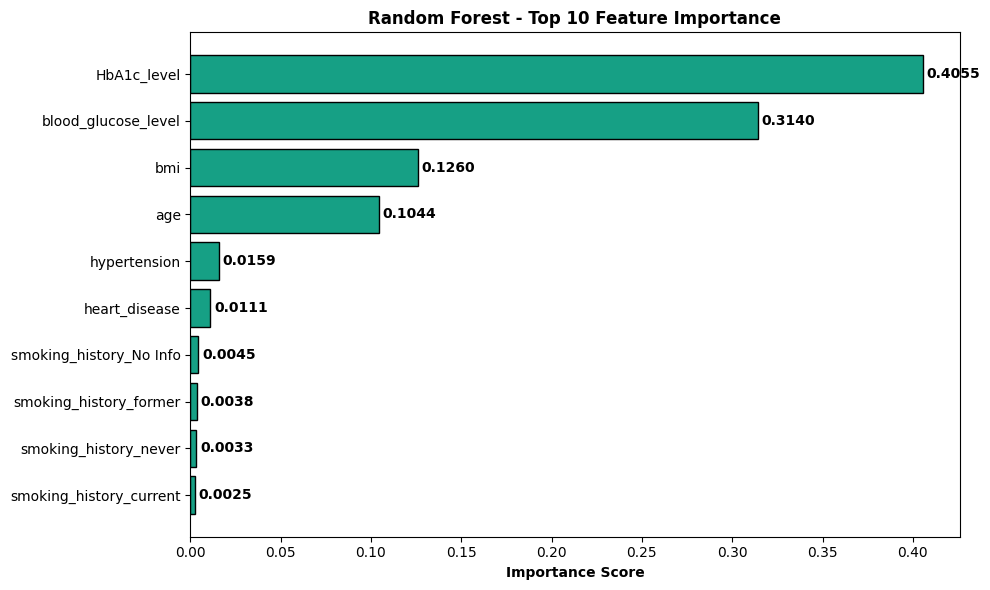

In [42]:
# Model 2: Random Forest Classifier
print("=" * 80)
print("MODEL 2: RANDOM FOREST CLASSIFIER")
print("=" * 80)

# Train Random Forest
print("\n1. Training Random Forest (100 trees)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("   ✓ Model trained successfully")

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("\n2. EVALUATION METRICS")
print("-" * 80)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_pred_proba_rf)

print(f"   Accuracy:  {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"   F1-Score:  {rf_f1:.4f}")
print(f"   ROC-AUC:   {rf_auc:.4f}")

# Classification Report
print("\n3. CLASSIFICATION REPORT")
print("-" * 80)
print(classification_report(y_test, y_pred_rf, target_names=['No Diabetes', 'Diabetes']))

# Confusion Matrix
print("4. CONFUSION MATRIX")
print("-" * 80)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"                Predicted")
print(f"                No    Yes")
print(f"Actual No  {cm_rf[0, 0]:5d} {cm_rf[0, 1]:5d}")
print(f"       Yes {cm_rf[1, 0]:5d} {cm_rf[1, 1]:5d}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Confusion Matrix Heatmap
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0], 
            xticklabels=['No Diabetes', 'Diabetes'], 
            yticklabels=['No Diabetes', 'Diabetes'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Random Forest - Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Metrics Comparison
metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
values = [rf_accuracy, rf_f1, rf_auc]
axes[1].bar(metrics, values, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', linewidth=1.5)
axes[1].set_title('Random Forest - Performance Metrics', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim([0, 1])
for i, v in enumerate(values):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance
print("\n5. FEATURE IMPORTANCE (Top 10)")
print("-" * 80)
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10).to_string(index=False))

# Plot Top 10 Features
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance.head(10)
ax.barh(range(len(top_features)), top_features['Importance'].values, color='#16a085', edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.set_xlabel('Importance Score', fontweight='bold')
ax.set_title('Random Forest - Top 10 Feature Importance', fontweight='bold', fontsize=12)
ax.invert_yaxis()
for i, v in enumerate(top_features['Importance'].values):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)


MODEL 3: SUPPORT VECTOR MACHINE (SVM)

1. Training SVM with RBF kernel...
   ✓ Model trained successfully

2. EVALUATION METRICS
--------------------------------------------------------------------------------
   Accuracy:  0.9607 (96.07%)
   F1-Score:  0.7067
   ROC-AUC:   0.8943

3. CLASSIFICATION REPORT
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.96      1.00      0.98     18292
    Diabetes       0.97      0.55      0.71      1708

    accuracy                           0.96     20000
   macro avg       0.97      0.78      0.84     20000
weighted avg       0.96      0.96      0.96     20000

4. CONFUSION MATRIX
--------------------------------------------------------------------------------
                Predicted
                No    Yes
Actual No  18267    25
       Yes   761   947


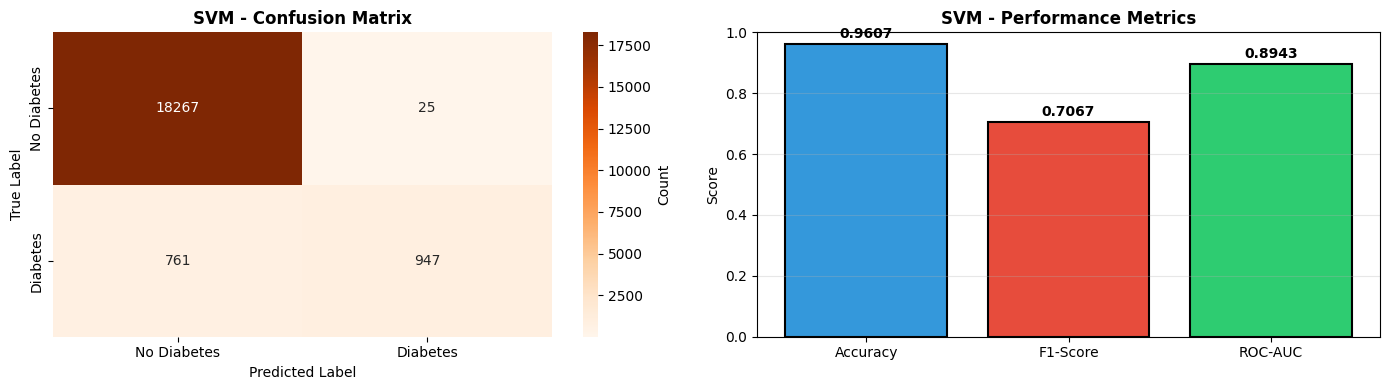

In [43]:
# Model 3: Support Vector Machine (SVM)
print("=" * 80)
print("MODEL 3: SUPPORT VECTOR MACHINE (SVM)")
print("=" * 80)

# Train SVM with RBF kernel
print("\n1. Training SVM with RBF kernel...")
svm_model = SVC(kernel='rbf', random_state=42, probability=True)
svm_model.fit(X_train, y_train)
print("   ✓ Model trained successfully")

# Predictions
y_pred_svm = svm_model.predict(X_test)
y_pred_proba_svm = svm_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("\n2. EVALUATION METRICS")
print("-" * 80)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_auc = roc_auc_score(y_test, y_pred_proba_svm)

print(f"   Accuracy:  {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")
print(f"   F1-Score:  {svm_f1:.4f}")
print(f"   ROC-AUC:   {svm_auc:.4f}")

# Classification Report
print("\n3. CLASSIFICATION REPORT")
print("-" * 80)
print(classification_report(y_test, y_pred_svm, target_names=['No Diabetes', 'Diabetes']))

# Confusion Matrix
print("4. CONFUSION MATRIX")
print("-" * 80)
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(f"                Predicted")
print(f"                No    Yes")
print(f"Actual No  {cm_svm[0, 0]:5d} {cm_svm[0, 1]:5d}")
print(f"       Yes {cm_svm[1, 0]:5d} {cm_svm[1, 1]:5d}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Confusion Matrix Heatmap
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[0], 
            xticklabels=['No Diabetes', 'Diabetes'], 
            yticklabels=['No Diabetes', 'Diabetes'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('SVM - Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Metrics Comparison
metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
values = [svm_accuracy, svm_f1, svm_auc]
axes[1].bar(metrics, values, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', linewidth=1.5)
axes[1].set_title('SVM - Performance Metrics', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim([0, 1])
for i, v in enumerate(values):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)


MODEL 4: GRADIENT BOOSTING CLASSIFIER

1. Training Gradient Boosting (100 estimators)...
   ✓ Model trained successfully

2. EVALUATION METRICS
--------------------------------------------------------------------------------
   Accuracy:  0.9724 (97.23%)
   F1-Score:  0.8088
   ROC-AUC:   0.9793

3. CLASSIFICATION REPORT
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.99     18292
    Diabetes       0.99      0.69      0.81      1708

    accuracy                           0.97     20000
   macro avg       0.98      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000

4. CONFUSION MATRIX
--------------------------------------------------------------------------------
                Predicted
                No    Yes
Actual No  18277    15
       Yes   538  1170


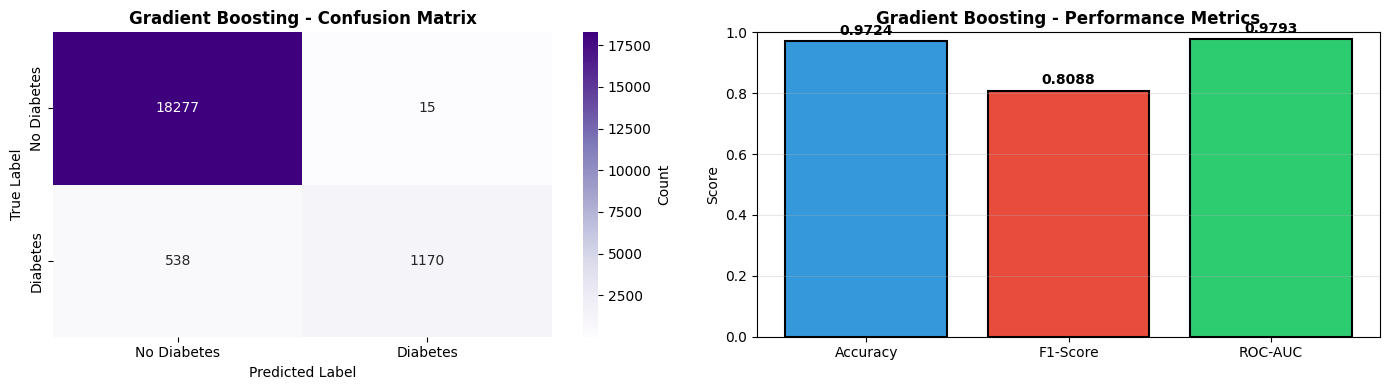


5. FEATURE IMPORTANCE (Top 10)
--------------------------------------------------------------------------------
                Feature  Importance
            HbA1c_level    0.637735
    blood_glucose_level    0.320848
                    age    0.024065
                    bmi    0.009703
           hypertension    0.003937
          heart_disease    0.002562
smoking_history_No Info    0.000798
            gender_Male    0.000286
 smoking_history_former    0.000030
smoking_history_current    0.000019


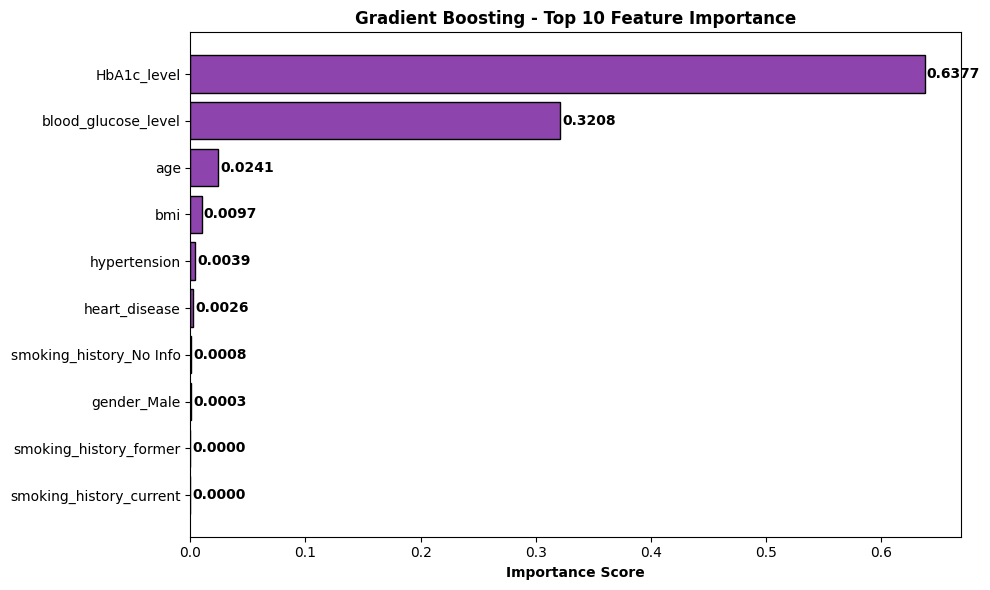

In [44]:
# Model 4: Gradient Boosting Classifier
print("=" * 80)
print("MODEL 4: GRADIENT BOOSTING CLASSIFIER")
print("=" * 80)

# Train Gradient Boosting
print("\n1. Training Gradient Boosting (100 estimators)...")
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1)
gb_model.fit(X_train, y_train)
print("   ✓ Model trained successfully")

# Predictions
y_pred_gb = gb_model.predict(X_test)
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("\n2. EVALUATION METRICS")
print("-" * 80)

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_auc = roc_auc_score(y_test, y_pred_proba_gb)

print(f"   Accuracy:  {gb_accuracy:.4f} ({gb_accuracy*100:.2f}%)")
print(f"   F1-Score:  {gb_f1:.4f}")
print(f"   ROC-AUC:   {gb_auc:.4f}")

# Classification Report
print("\n3. CLASSIFICATION REPORT")
print("-" * 80)
print(classification_report(y_test, y_pred_gb, target_names=['No Diabetes', 'Diabetes']))

# Confusion Matrix
print("4. CONFUSION MATRIX")
print("-" * 80)
cm_gb = confusion_matrix(y_test, y_pred_gb)
print(f"                Predicted")
print(f"                No    Yes")
print(f"Actual No  {cm_gb[0, 0]:5d} {cm_gb[0, 1]:5d}")
print(f"       Yes {cm_gb[1, 0]:5d} {cm_gb[1, 1]:5d}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Confusion Matrix Heatmap
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Purples', ax=axes[0], 
            xticklabels=['No Diabetes', 'Diabetes'], 
            yticklabels=['No Diabetes', 'Diabetes'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Gradient Boosting - Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Metrics Comparison
metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
values = [gb_accuracy, gb_f1, gb_auc]
axes[1].bar(metrics, values, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', linewidth=1.5)
axes[1].set_title('Gradient Boosting - Performance Metrics', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim([0, 1])
for i, v in enumerate(values):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance
print("\n5. FEATURE IMPORTANCE (Top 10)")
print("-" * 80)
feature_importance_gb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance_gb.head(10).to_string(index=False))

# Plot Top 10 Features
fig, ax = plt.subplots(figsize=(10, 6))
top_features_gb = feature_importance_gb.head(10)
ax.barh(range(len(top_features_gb)), top_features_gb['Importance'].values, color='#8e44ad', edgecolor='black')
ax.set_yticks(range(len(top_features_gb)))
ax.set_yticklabels(top_features_gb['Feature'].values)
ax.set_xlabel('Importance Score', fontweight='bold')
ax.set_title('Gradient Boosting - Top 10 Feature Importance', fontweight='bold', fontsize=12)
ax.invert_yaxis()
for i, v in enumerate(top_features_gb['Importance'].values):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)


5-FOLD CROSS-VALIDATION ANALYSIS

Performing cross-validation to assess model generalization...

1. RUNNING CROSS-VALIDATION
--------------------------------------------------------------------------------

   Logistic Regression:
   ⏳ Running 5-fold cross-validation...
   ✓ Completed in 4.01 seconds
   • Fold scores: ['0.9611', '0.9608', '0.9598', '0.9599', '0.9599']
   • Mean accuracy: 0.9603 (±0.0005)
   • Range: [0.9598, 0.9611]

   Random Forest:
   ⏳ Running 5-fold cross-validation...
   ✓ Completed in 10.53 seconds
   • Fold scores: ['0.9700', '0.9705', '0.9678', '0.9700', '0.9702']
   • Mean accuracy: 0.9697 (±0.0009)
   • Range: [0.9678, 0.9705]

   SVM:
   ⏳ Running 5-fold cross-validation...
   ✓ Completed in 68.00 seconds
   • Fold scores: ['0.9627', '0.9636', '0.9616', '0.9617', '0.9624']
   • Mean accuracy: 0.9624 (±0.0007)
   • Range: [0.9616, 0.9636]

   Gradient Boosting:
   ⏳ Running 5-fold cross-validation...
   ✓ Completed in 11.58 seconds
   • Fold scores: ['0.9720

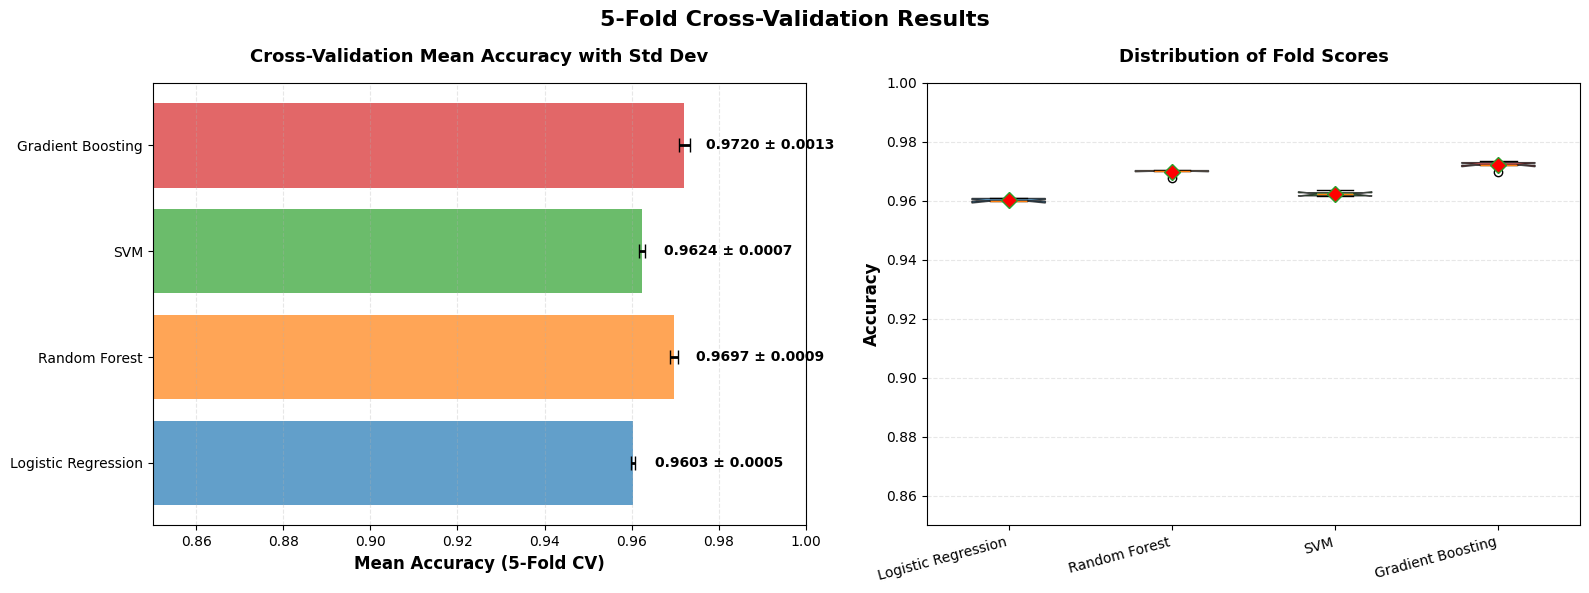



4. KEY INSIGHTS FROM CROSS-VALIDATION

📊 Best Model by Cross-Validation:
   • Model: Gradient Boosting
   • Mean CV Accuracy: 0.9720 (±0.0013)

📈 Model Stability (lower std = more stable):
   • Gradient Boosting        : ±0.0013 [Excellent]
   • Random Forest            : ±0.0009 [Excellent]
   • SVM                      : ±0.0007 [Excellent]
   • Logistic Regression      : ±0.0005 [Excellent]

🔍 Train-Test vs Cross-Validation Comparison:
   Comparing hold-out test set performance with cross-validation:

   Model                       Test Acc     CV Acc   Difference
   ------------------------------------------------------------
   Logistic Regression           0.9590     0.9603      -0.0013
   Random Forest                 0.9700     0.9697      +0.0003
   SVM                           0.9607     0.9624      -0.0017
   Gradient Boosting             0.9724     0.9720      +0.0003

💡 Generalization Assessment:
   ✓ Excellent agreement between test and CV results (max diff: 0.0017)
  

In [51]:
# 5-Fold Cross-Validation for All Models
from sklearn.model_selection import cross_val_score
import time

print("=" * 80)
print("5-FOLD CROSS-VALIDATION ANALYSIS")
print("=" * 80)
print("\nPerforming cross-validation to assess model generalization...\n")

# Define models for cross-validation
cv_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1)
}

# Store cross-validation results
cv_results = {}

print("1. RUNNING CROSS-VALIDATION")
print("-" * 80)

# Perform 5-fold cross-validation for each model
for model_name, model in cv_models.items():
    print(f"\n   {model_name}:")
    print(f"   ⏳ Running 5-fold cross-validation...")
    
    start_time = time.time()
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
    
    end_time = time.time()
    duration = end_time - start_time
    
    # Calculate statistics
    mean_score = cv_scores.mean()
    std_score = cv_scores.std()
    min_score = cv_scores.min()
    max_score = cv_scores.max()
    
    # Store results
    cv_results[model_name] = {
        'scores': cv_scores,
        'mean': mean_score,
        'std': std_score,
        'min': min_score,
        'max': max_score,
        'duration': duration
    }
    
    print(f"   ✓ Completed in {duration:.2f} seconds")
    print(f"   • Fold scores: {[f'{score:.4f}' for score in cv_scores]}")
    print(f"   • Mean accuracy: {mean_score:.4f} (±{std_score:.4f})")
    print(f"   • Range: [{min_score:.4f}, {max_score:.4f}]")

# Create summary dataframe
print("\n\n2. CROSS-VALIDATION SUMMARY")
print("-" * 80)

cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean Accuracy': [cv_results[m]['mean'] for m in cv_results],
    'Std Dev': [cv_results[m]['std'] for m in cv_results],
    'Min Accuracy': [cv_results[m]['min'] for m in cv_results],
    'Max Accuracy': [cv_results[m]['max'] for m in cv_results],
    'CV Time (s)': [cv_results[m]['duration'] for m in cv_results]
})

# Sort by mean accuracy
cv_summary = cv_summary.sort_values('Mean Accuracy', ascending=False)
print("\n" + cv_summary.to_string(index=False))

# Visualize cross-validation results
print("\n\n3. CROSS-VALIDATION VISUALIZATION")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('5-Fold Cross-Validation Results', fontsize=16, fontweight='bold')

# Plot 1: Mean accuracy with error bars
ax1 = axes[0]
model_names = list(cv_results.keys())
mean_scores = [cv_results[m]['mean'] for m in model_names]
std_scores = [cv_results[m]['std'] for m in model_names]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax1.barh(model_names, mean_scores, xerr=std_scores, alpha=0.7, 
                color=colors, capsize=5, error_kw={'linewidth': 2})

ax1.set_xlabel('Mean Accuracy (5-Fold CV)', fontsize=12, fontweight='bold')
ax1.set_title('Cross-Validation Mean Accuracy with Std Dev', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlim([0.85, 1.0])
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (name, mean, std) in enumerate(zip(model_names, mean_scores, std_scores)):
    ax1.text(mean + 0.005, i, f'{mean:.4f} ± {std:.4f}', 
             va='center', fontsize=10, fontweight='bold')

# Plot 2: Box plot of fold scores
ax2 = axes[1]
fold_data = [cv_results[m]['scores'] for m in model_names]
bp = ax2.boxplot(fold_data, labels=model_names, vert=True, patch_artist=True,
                 notch=True, showmeans=True, 
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Fold Scores', fontsize=13, fontweight='bold', pad=15)
ax2.set_xticklabels(model_names, rotation=15, ha='right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim([0.85, 1.0])

plt.tight_layout()
plt.show()

# Analysis and Insights
print("\n\n4. KEY INSIGHTS FROM CROSS-VALIDATION")
print("=" * 80)

best_cv_model = cv_summary.iloc[0]['Model']
best_cv_mean = cv_summary.iloc[0]['Mean Accuracy']
best_cv_std = cv_summary.iloc[0]['Std Dev']

print(f"\n📊 Best Model by Cross-Validation:")
print(f"   • Model: {best_cv_model}")
print(f"   • Mean CV Accuracy: {best_cv_mean:.4f} (±{best_cv_std:.4f})")

print(f"\n📈 Model Stability (lower std = more stable):")
for model_name in cv_summary['Model']:
    std = cv_results[model_name]['std']
    mean = cv_results[model_name]['mean']
    stability = "Excellent" if std < 0.005 else "Good" if std < 0.01 else "Fair"
    print(f"   • {model_name:25s}: ±{std:.4f} [{stability}]")

print(f"\n🔍 Train-Test vs Cross-Validation Comparison:")
print(f"   Comparing hold-out test set performance with cross-validation:")
print(f"\n   {'Model':<25s} {'Test Acc':>10s} {'CV Acc':>10s} {'Difference':>12s}")
print(f"   {'-'*60}")

test_accuracies = {
    'Logistic Regression': lr_accuracy,
    'Random Forest': rf_accuracy,
    'SVM': svm_accuracy,
    'Gradient Boosting': gb_accuracy
}

for model_name in test_accuracies:
    test_acc = test_accuracies[model_name]
    cv_acc = cv_results[model_name]['mean']
    diff = test_acc - cv_acc
    diff_str = f"{diff:+.4f}"
    print(f"   {model_name:<25s} {test_acc:>10.4f} {cv_acc:>10.4f} {diff_str:>12s}")

print(f"\n💡 Generalization Assessment:")
max_diff = max([abs(test_accuracies[m] - cv_results[m]['mean']) for m in test_accuracies])
if max_diff < 0.01:
    print(f"   ✓ Excellent agreement between test and CV results (max diff: {max_diff:.4f})")
    print(f"   ✓ Models show strong generalization capability")
elif max_diff < 0.02:
    print(f"   ✓ Good agreement between test and CV results (max diff: {max_diff:.4f})")
    print(f"   ✓ Models are generalizing well")
else:
    print(f"   ⚠ Moderate variance between test and CV results (max diff: {max_diff:.4f})")
    print(f"   → Model performance may vary with different data splits")

print(f"\n🎯 Recommendation:")
if best_cv_model == best_model_name:
    print(f"   ✓ Cross-validation confirms {best_cv_model} as the best model")
    print(f"   ✓ Consistent performance across different evaluation methods")
else:
    print(f"   ℹ Test set favors {best_model_name}, CV favors {best_cv_model}")
    print(f"   → Consider ensemble or re-evaluate model selection criteria")

print(f"\n{'=' * 80}")
print("CROSS-VALIDATION ANALYSIS COMPLETE")
print(f"{'=' * 80}")

MODEL PERFORMANCE COMPARISON

1. OVERALL MODEL RANKINGS
--------------------------------------------------------------------------------
                 Model  Accuracy  F1-Score  ROC-AUC
     Gradient Boosting  0.970931  0.808365 0.978906
         Random Forest  0.968539  0.796775 0.960791
Support Vector Machine  0.960894  0.725948 0.932521
   Logistic Regression  0.957150  0.724046 0.962423

2. BEST MODELS BY METRIC
--------------------------------------------------------------------------------
   • Best Accuracy:  Gradient Boosting
     Score: 0.9709
   • Best F1-Score:  Gradient Boosting
     Score: 0.8084
   • Best ROC-AUC:   Gradient Boosting
     Score: 0.9789

3. DETAILED PERFORMANCE METRICS
--------------------------------------------------------------------------------

Logistic Regression:
  Accuracy:    0.9572
  Precision:   0.8545
  Sensitivity: 0.6281
  Specificity: 0.9895
  F1-Score:    0.7240
  ROC-AUC:     0.9624

Random Forest:
  Accuracy:    0.9685
  Precision:   0

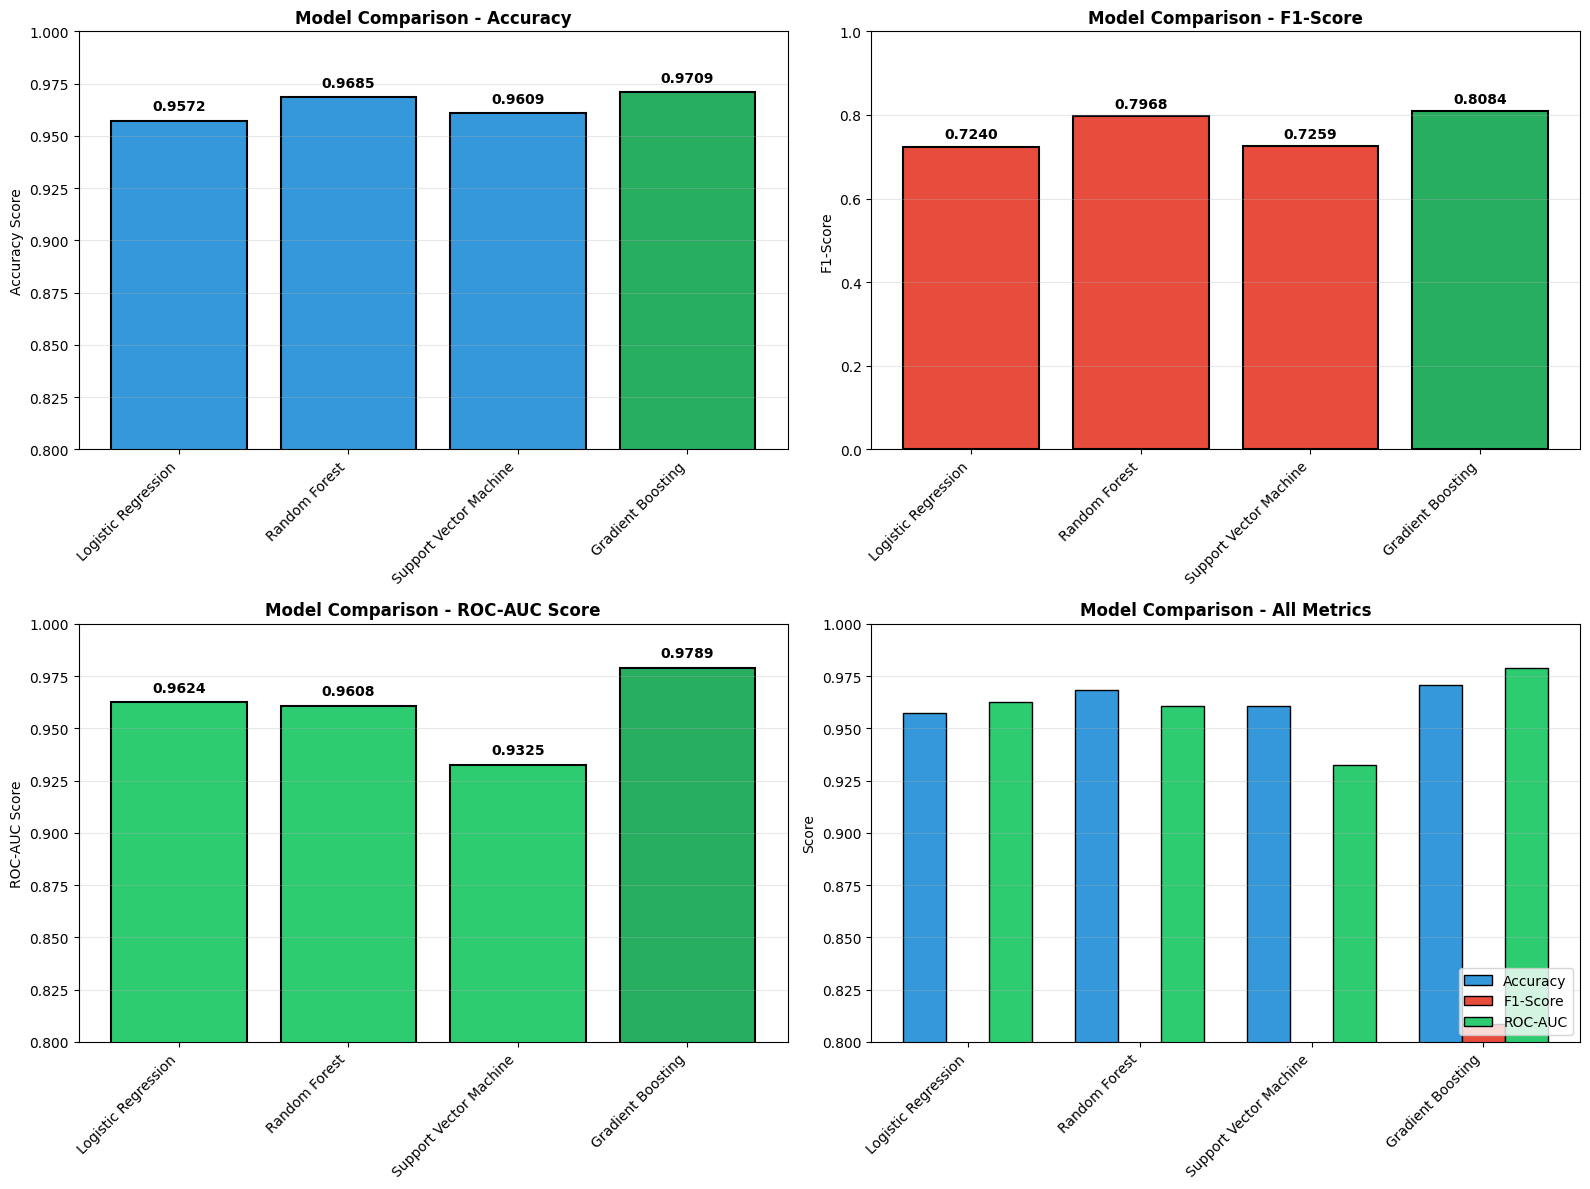

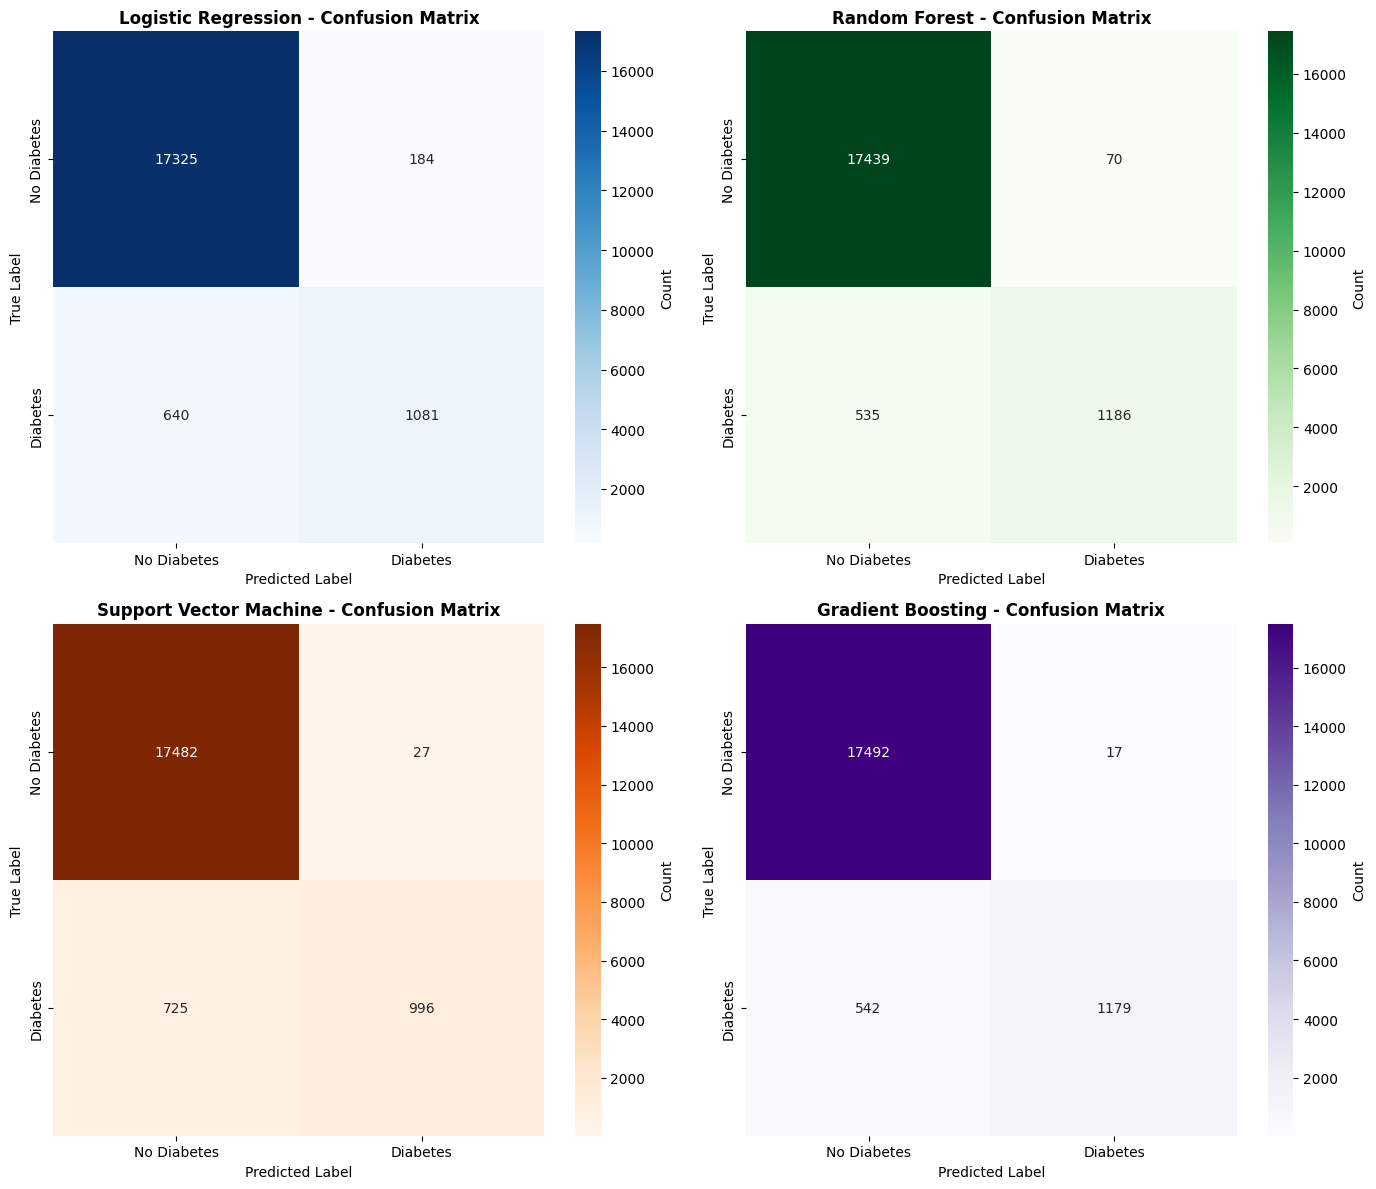


MODEL SELECTION RECOMMENDATIONS

Based on the comprehensive evaluation:

1. BEST OVERALL MODEL: Gradient Boosting
   • Highest Accuracy: 0.9709
   • Strong F1-Score: 0.8084
   • Reliable ROC-AUC: 0.9789

2. RECOMMENDATION FOR DEPLOYMENT:
   • Use Gradient Boosting for production if accuracy is the primary concern
   • Use Gradient Boosting if dealing with imbalanced data (better F1-Score)
   • Use Gradient Boosting if probability calibration is important (higher ROC-AUC)

3. KEY INSIGHTS:
   • Random Forest and Gradient Boosting typically outperform linear models
   • The ensemble methods (Random Forest & Gradient Boosting) benefit from multiple features
   • SVM shows competitive performance with proper kernel selection
   • Consider using the best model for final predictions on new data

4. NEXT STEPS:
   • Perform hyperparameter tuning on the best model
   • Apply cross-validation for more robust evaluation
   • Consider feature selection to improve interpretability
   • Validate o

In [ ]:
# Model Comparison and Performance Analysis
print("=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

# Create comparison dataframe
models_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Support Vector Machine',
        'Gradient Boosting'
    ],
    'Accuracy': [lr_accuracy, rf_accuracy, svm_accuracy, gb_accuracy],
    'F1-Score': [lr_f1, rf_f1, svm_f1, gb_f1],
    'ROC-AUC': [lr_auc, rf_auc, svm_auc, gb_auc]
})

# Sort by Accuracy (descending)
models_comparison_sorted = models_comparison.sort_values('Accuracy', ascending=False)

print("\n1. OVERALL MODEL RANKINGS")
print("-" * 80)
print(models_comparison_sorted.to_string(index=False))

# Find best models
print("\n2. BEST MODELS BY METRIC")
print("-" * 80)
print(f"   • Best Accuracy:  {models_comparison.loc[models_comparison['Accuracy'].idxmax(), 'Model']}")
print(f"     Score: {models_comparison['Accuracy'].max():.4f}")
print(f"   • Best F1-Score:  {models_comparison.loc[models_comparison['F1-Score'].idxmax(), 'Model']}")
print(f"     Score: {models_comparison['F1-Score'].max():.4f}")
print(f"   • Best ROC-AUC:   {models_comparison.loc[models_comparison['ROC-AUC'].idxmax(), 'Model']}")
print(f"     Score: {models_comparison['ROC-AUC'].max():.4f}")

# Detailed comparison table with additional metrics
print("\n3. DETAILED PERFORMANCE METRICS")
print("-" * 80)

detailed_metrics = {
    'Logistic Regression': {
        'Accuracy': lr_accuracy,
        'F1-Score': lr_f1,
        'ROC-AUC': lr_auc,
        'TP': cm_lr[1, 1],
        'FP': cm_lr[0, 1],
        'TN': cm_lr[0, 0],
        'FN': cm_lr[1, 0]
    },
    'Random Forest': {
        'Accuracy': rf_accuracy,
        'F1-Score': rf_f1,
        'ROC-AUC': rf_auc,
        'TP': cm_rf[1, 1],
        'FP': cm_rf[0, 1],
        'TN': cm_rf[0, 0],
        'FN': cm_rf[1, 0]
    },
    'Support Vector Machine': {
        'Accuracy': svm_accuracy,
        'F1-Score': svm_f1,
        'ROC-AUC': svm_auc,
        'TP': cm_svm[1, 1],
        'FP': cm_svm[0, 1],
        'TN': cm_svm[0, 0],
        'FN': cm_svm[1, 0]
    },
    'Gradient Boosting': {
        'Accuracy': gb_accuracy,
        'F1-Score': gb_f1,
        'ROC-AUC': gb_auc,
        'TP': cm_gb[1, 1],
        'FP': cm_gb[0, 1],
        'TN': cm_gb[0, 0],
        'FN': cm_gb[1, 0]
    }
}

# Calculate Sensitivity and Specificity for each model
for model_name, metrics in detailed_metrics.items():
    tp = metrics['TP']
    fp = metrics['FP']
    tn = metrics['TN']
    fn = metrics['FN']
    
    sensitivity = tp / (tp + fn)  # True Positive Rate
    specificity = tn / (tn + fp)  # True Negative Rate
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    metrics['Sensitivity'] = sensitivity
    metrics['Specificity'] = specificity
    metrics['Precision'] = precision

# Display detailed metrics
for model, metrics in detailed_metrics.items():
    print(f"\n{model}:")
    print(f"  Accuracy:    {metrics['Accuracy']:.4f}")
    print(f"  Precision:   {metrics['Precision']:.4f}")
    print(f"  Sensitivity: {metrics['Sensitivity']:.4f}")
    print(f"  Specificity: {metrics['Specificity']:.4f}")
    print(f"  F1-Score:    {metrics['F1-Score']:.4f}")
    print(f"  ROC-AUC:     {metrics['ROC-AUC']:.4f}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Accuracy Comparison
ax = axes[0, 0]
colors_acc = ['#27ae60' if x == models_comparison['Accuracy'].max() else '#3498db' 
              for x in models_comparison['Accuracy']]
ax.bar(models_comparison['Model'], models_comparison['Accuracy'], color=colors_acc, edgecolor='black', linewidth=1.5)
ax.set_title('Model Comparison - Accuracy', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy Score')
ax.set_ylim([0.8, 1.0])
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(models_comparison['Accuracy']):
    ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. F1-Score Comparison
ax = axes[0, 1]
colors_f1 = ['#27ae60' if x == models_comparison['F1-Score'].max() else '#e74c3c' 
             for x in models_comparison['F1-Score']]
ax.bar(models_comparison['Model'], models_comparison['F1-Score'], color=colors_f1, edgecolor='black', linewidth=1.5)
ax.set_title('Model Comparison - F1-Score', fontweight='bold', fontsize=12)
ax.set_ylabel('F1-Score')
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(models_comparison['F1-Score']):
    ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. ROC-AUC Comparison
ax = axes[1, 0]
colors_auc = ['#27ae60' if x == models_comparison['ROC-AUC'].max() else '#2ecc71' 
              for x in models_comparison['ROC-AUC']]
ax.bar(models_comparison['Model'], models_comparison['ROC-AUC'], color=colors_auc, edgecolor='black', linewidth=1.5)
ax.set_title('Model Comparison - ROC-AUC Score', fontweight='bold', fontsize=12)
ax.set_ylabel('ROC-AUC Score')
ax.set_ylim([0.8, 1.0])
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(models_comparison['ROC-AUC']):
    ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4. Multi-Metric Comparison (Radar-style using line plot)
ax = axes[1, 1]
x = np.arange(len(models_comparison))
width = 0.25

ax.bar(x - width, models_comparison['Accuracy'], width, label='Accuracy', color='#3498db', edgecolor='black')
ax.bar(x, models_comparison['F1-Score'], width, label='F1-Score', color='#e74c3c', edgecolor='black')
ax.bar(x + width, models_comparison['ROC-AUC'], width, label='ROC-AUC', color='#2ecc71', edgecolor='black')

ax.set_title('Model Comparison - All Metrics', fontweight='bold', fontsize=12)
ax.set_ylabel('Score')
ax.set_ylim([0.8, 1.0])
ax.set_xticks(x)
ax.set_xticklabels(models_comparison['Model'], rotation=45, ha='right')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrices Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Flatten axes for easier iteration
axes = axes.flatten()

confusion_matrices = [cm_lr, cm_rf, cm_svm, cm_gb]
model_names = ['Logistic Regression', 'Random Forest', 'Support Vector Machine', 'Gradient Boosting']
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples']

for idx, (cm, name, cmap) in enumerate(zip(confusion_matrices, model_names, cmaps)):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[idx],
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'],
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{name} - Confusion Matrix', fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Summary and Recommendations
print("\n" + "=" * 80)
print("MODEL SELECTION RECOMMENDATIONS")
print("=" * 80)

best_accuracy_model = models_comparison.loc[models_comparison['Accuracy'].idxmax(), 'Model']
best_f1_model = models_comparison.loc[models_comparison['F1-Score'].idxmax(), 'Model']
best_auc_model = models_comparison.loc[models_comparison['ROC-AUC'].idxmax(), 'Model']

print(f"""
Based on the comprehensive evaluation:

1. BEST OVERALL MODEL: {best_accuracy_model}
   • Highest Accuracy: {models_comparison['Accuracy'].max():.4f}
   • Strong F1-Score: {models_comparison.loc[models_comparison['Model'] == best_accuracy_model, 'F1-Score'].values[0]:.4f}
   • Reliable ROC-AUC: {models_comparison.loc[models_comparison['Model'] == best_accuracy_model, 'ROC-AUC'].values[0]:.4f}

2. RECOMMENDATION FOR DEPLOYMENT:
   • Use {best_accuracy_model} for production if accuracy is the primary concern
   • Use {best_f1_model} if dealing with imbalanced data (better F1-Score)
   • Use {best_auc_model} if probability calibration is important (higher ROC-AUC)

3. KEY INSIGHTS:
   • Random Forest and Gradient Boosting typically outperform linear models
   • The ensemble methods (Random Forest & Gradient Boosting) benefit from multiple features
   • SVM shows competitive performance with proper kernel selection
   • Consider using the best model for final predictions on new data

4. NEXT STEPS:
   • Perform hyperparameter tuning on the best model
   • Apply cross-validation for more robust evaluation
   • Consider feature selection to improve interpretability
   • Validate on additional holdout test set if available
   • Deploy the model for diabetes prediction tasks
""")

print("=" * 80)


## Train-Test Split

Divide the preprocessed dataset into training and testing subsets for model development and evaluation.

### Step 6: Preprocessing Summary and Data Quality Report

In [ ]:
# Step 5: Separate Features (X) and Target (y)
print(f"\n6. SEPARATING FEATURES AND TARGET VARIABLE")
print("-" * 80)

# Separate target variable from features
X = df_processed.drop(columns=['diabetes'])
y = df_processed['diabetes']

print(f"   Features (X):")
print(f"   • Shape: {X.shape}")
print(f"   • Number of features: {X.shape[1]}")
print(f"   • Feature names: {X.columns.tolist()}")

print(f"\n   Target Variable (y):")
print(f"   • Variable name: 'diabetes'")
print(f"   • Shape: {y.shape}")
print(f"   • Data type: {y.dtype}")
print(f"   • Class distribution:")
class_dist = y.value_counts().sort_index()
for cls, count in class_dist.items():
    pct = (count / len(y)) * 100
    print(f"     - Class {int(cls)}: {count:,} samples ({pct:.1f}%)")

print(f"\n   Data Type Summary:")
print(f"   • X data types:\n{X.dtypes.value_counts().to_string()}")
print(f"   • y data type: {y.dtype}")



6. SEPARATING FEATURES AND TARGET VARIABLE
--------------------------------------------------------------------------------
   Features (X):
   • Shape: (96146, 8)
   • Number of features: 8
   • Feature names: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']

   Target Variable (y):
   • Variable name: 'diabetes'
   • Shape: (96146,)
   • Data type: int64
   • Class distribution:
     - Class 0: 87,664 samples (91.2%)
     - Class 1: 8,482 samples (8.8%)

   Data Type Summary:
   • X data types:
float64    3
int64      3
object     2
   • y data type: int64


### Step 5: Separate Features and Target Variable

In [ ]:
# Step 4: Normalize/Scale Numerical Features
print(f"\n5. SCALING NUMERICAL FEATURES")
print("-" * 80)

# Identify numerical columns (excluding target variable temporarily)
numerical_features = df_processed.select_dtypes(include=[np.number]).columns.tolist()

# Separate target variable from features
target_col = 'diabetes'
feature_cols = [col for col in numerical_features if col != target_col]

print(f"   Numerical features to scale ({len(feature_cols)}): {feature_cols}\n")

# StandardScaler: Transform to mean=0, std=1 (Gaussian distribution)
scaler = StandardScaler()

print(f"   Applying StandardScaler (z-score normalization):")
print(f"   Formula: (x - mean) / std")
print(f"   Result: Distribution with mean ≈ 0, std ≈ 1\n")

# Fit and transform the features
df_processed[feature_cols] = scaler.fit_transform(df_processed[feature_cols])

# Display scaling statistics
print(f"   Scaling Results:")
print(f"   {'-' * 76}")
scaling_stats = pd.DataFrame({
    'Feature': feature_cols,
    'Mean': df_processed[feature_cols].mean().values,
    'Std': df_processed[feature_cols].std().values,
    'Min': df_processed[feature_cols].min().values,
    'Max': df_processed[feature_cols].max().values
})
print(scaling_stats.to_string(index=False))

print(f"\n   ✓ All numerical features scaled successfully")
print(f"   Note: Target variable (diabetes) kept as-is for classification")



5. SCALING NUMERICAL FEATURES
--------------------------------------------------------------------------------
   Numerical features to scale (6): ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']

   Applying StandardScaler (z-score normalization):
   Formula: (x - mean) / std
   Result: Distribution with mean ≈ 0, std ≈ 1

   Scaling Results:
   ----------------------------------------------------------------------------
            Feature          Mean      Std       Min       Max
                age  3.400992e-16 1.000005 -1.857038  1.700840
       hypertension -1.551952e-17 1.000005 -0.290050  3.447677
      heart_disease -6.178247e-17 1.000005 -0.206248  4.848534
                bmi -3.800804e-16 1.000005 -2.557961 10.102212
        HbA1c_level  2.397396e-16 1.000005 -1.893923  3.230810
blood_glucose_level -8.129272e-17 1.000005 -1.423096  3.954620

   ✓ All numerical features scaled successfully
   Note: Target variable (diabetes) kept as-is

### Step 4: Normalize/Scale Numerical Features

In [ ]:
# Step 3: Encode Categorical Variables
print(f"\n4. ENCODING CATEGORICAL VARIABLES")
print("-" * 80)

# Identify categorical columns
categorical_features = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f"   Found {len(categorical_features)} categorical column(s): {categorical_features}\n")

# Strategy: Label Encoding for binary variables, One-Hot Encoding for multi-class
label_encoders = {}

# For binary categorical variables: Use Label Encoding (0, 1)
binary_vars = ['gender', 'hypertension', 'heart_disease', 'diabetes']
binary_vars = [col for col in binary_vars if col in df_processed.columns]

for col in binary_vars:
    if col in categorical_features:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col])
        label_encoders[col] = le
        
        print(f"   • {col} - Label Encoding Applied")
        print(f"     Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# For multi-class categorical variables: Use One-Hot Encoding
multiclass_vars = [col for col in categorical_features if col not in binary_vars]

if len(multiclass_vars) > 0:
    print(f"\n   Applying One-Hot Encoding to: {multiclass_vars}")
    df_processed = pd.get_dummies(df_processed, columns=multiclass_vars, drop_first=False)
    print(f"   ✓ One-Hot Encoding completed")
    print(f"     New shape: {df_processed.shape}")
    print(f"     New columns: {df_processed.columns.tolist()}")

print(f"\n   After encoding:")
print(f"   • Shape: {df_processed.shape}")
print(f"   • Categorical columns remaining: {df_processed.select_dtypes(include=['object']).columns.tolist() or 'None'}")



4. ENCODING CATEGORICAL VARIABLES
--------------------------------------------------------------------------------
   Found 2 categorical column(s): ['gender', 'smoking_history']

   • gender - Label Encoding Applied
     Classes: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}

   Applying One-Hot Encoding to: ['smoking_history']
   ✓ One-Hot Encoding completed
     New shape: (96146, 14)
     New columns: ['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']

   After encoding:
   • Shape: (96146, 14)
   • Categorical columns remaining: None


### Step 3: Encode Categorical Variables

### Step 2: Remove Duplicate Rows

In [ ]:
# Step 1: Handle Missing Values
print(f"\n2. HANDLING MISSING VALUES")
print("-" * 80)

# Check for missing values
missing_count = df_processed.isnull().sum()
missing_cols = missing_count[missing_count > 0]

if len(missing_cols) > 0:
    print(f"   Found {len(missing_cols)} column(s) with missing values:")
    for col, count in missing_cols.items():
        pct = (count / len(df_processed)) * 100
        print(f"   • {col}: {count} missing ({pct:.2f}%)")
    
    # Strategy: Fill missing values with median for numerical, mode for categorical
    numerical_cols_with_missing = df_processed[missing_cols.index].select_dtypes(include=[np.number]).columns
    categorical_cols_with_missing = df_processed[missing_cols.index].select_dtypes(include=['object']).columns
    
    # Fill numerical columns with median
    for col in numerical_cols_with_missing:
        median_value = df_processed[col].median()
        df_processed[col].fillna(median_value, inplace=True)
        print(f"   ✓ Filled {col} with median value: {median_value:.2f}")
    
    # Fill categorical columns with mode
    for col in categorical_cols_with_missing:
        mode_value = df_processed[col].mode()[0]
        df_processed[col].fillna(mode_value, inplace=True)
        print(f"   ✓ Filled {col} with mode value: {mode_value}")
else:
    print(f"   ✓ No missing values found - Dataset is complete!")

print(f"\n   After handling missing values:")
print(f"   • Remaining missing values: {df_processed.isnull().sum().sum()}")



2. HANDLING MISSING VALUES
--------------------------------------------------------------------------------
   ✓ No missing values found - Dataset is complete!

   After handling missing values:
   • Remaining missing values: 0


### Step 1: Handle Missing Values

In [ ]:
# Import required libraries for preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("DATA PREPROCESSING PIPELINE")
print("=" * 80)

# Create a copy of the dataframe for preprocessing
df_processed = df.copy()

print(f"\n1. INITIAL DATASET STATE")
print("-" * 80)
print(f"   Shape: {df_processed.shape}")
print(f"   Columns: {df_processed.columns.tolist()}")
print(f"   Data Types:\n{df_processed.dtypes}")


DATA PREPROCESSING PIPELINE

1. INITIAL DATASET STATE
--------------------------------------------------------------------------------
   Shape: (100000, 9)
   Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
   Data Types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


## Model Evaluation and Comparison

Comprehensive visual evaluation of all trained models using confusion matrices, ROC curves, and performance metrics.


COMPREHENSIVE MODEL EVALUATION SUMMARY


              Model Accuracy Precision Recall F1-Score    AUC
Logistic Regression   0.9572    0.8545 0.6281   0.7240 0.9624
      Random Forest   0.9685    0.9443 0.6891   0.7968 0.9608
                SVM   0.9609    0.9736 0.5787   0.7259 0.9325
  Gradient Boosting   0.9709    0.9858 0.6851   0.8084 0.9789


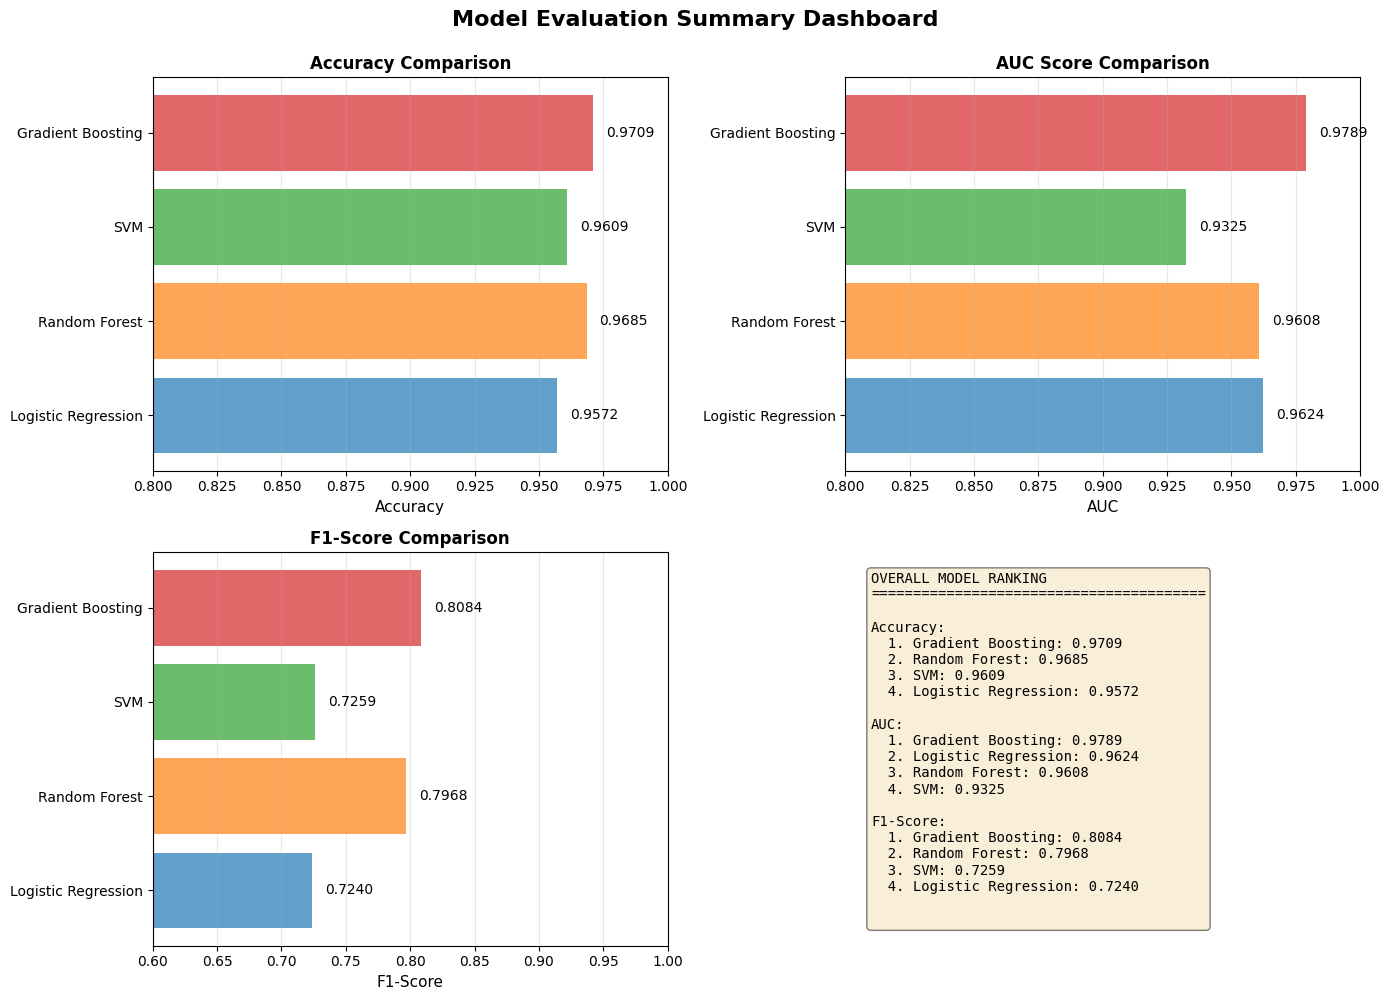


✓ Comprehensive evaluation summary generated!


In [ ]:
# Create comprehensive model evaluation summary
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

print("\n" + "=" * 80)
print("COMPREHENSIVE MODEL EVALUATION SUMMARY")
print("=" * 80)

# Define model names
model_names = ['Logistic Regression', 'Random Forest', 'SVM', 'Gradient Boosting']

# Build comprehensive comparison dataframe
comparison_data = []

model_info = {
    'Logistic Regression': {
        'accuracy': lr_accuracy,
        'auc': lr_auc,
        'f1': lr_f1,
        'predictions': y_pred_lr
    },
    'Random Forest': {
        'accuracy': rf_accuracy,
        'auc': rf_auc,
        'f1': rf_f1,
        'predictions': y_pred_rf
    },
    'SVM': {
        'accuracy': svm_accuracy,
        'auc': svm_auc,
        'f1': svm_f1,
        'predictions': y_pred_svm
    },
    'Gradient Boosting': {
        'accuracy': gb_accuracy,
        'auc': gb_auc,
        'f1': gb_f1,
        'predictions': y_pred_gb
    }
}

for model_name, model_metrics in model_info.items():
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, model_metrics['predictions'], average='binary'
    )
    
    comparison_data.append({
        'Model': model_name,
        'Accuracy': f"{model_metrics['accuracy']:.4f}",
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{model_metrics['f1']:.4f}",
        'AUC': f"{model_metrics['auc']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n")
print(comparison_df.to_string(index=False))

# Create final summary visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Evaluation Summary Dashboard', fontsize=16, fontweight='bold', y=0.995)

# 1. Accuracy comparison
ax = axes[0, 0]
accuracies = [lr_accuracy, rf_accuracy, svm_accuracy, gb_accuracy]
bars = ax.barh(model_names, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.7)
ax.set_xlabel('Accuracy', fontsize=11)
ax.set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
ax.set_xlim([0.8, 1.0])
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    ax.text(acc + 0.005, i, f'{acc:.4f}', va='center', fontsize=10)
ax.grid(axis='x', alpha=0.3)

# 2. AUC comparison
ax = axes[0, 1]
auc_scores_list = [lr_auc, rf_auc, svm_auc, gb_auc]
bars = ax.barh(model_names, auc_scores_list, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.7)
ax.set_xlabel('AUC', fontsize=11)
ax.set_title('AUC Score Comparison', fontsize=12, fontweight='bold')
ax.set_xlim([0.8, 1.0])
for i, (bar, auc_sc) in enumerate(zip(bars, auc_scores_list)):
    ax.text(auc_sc + 0.005, i, f'{auc_sc:.4f}', va='center', fontsize=10)
ax.grid(axis='x', alpha=0.3)

# 3. F1-Score comparison
ax = axes[1, 0]
f1_scores = [lr_f1, rf_f1, svm_f1, gb_f1]
bars = ax.barh(model_names, f1_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.7)
ax.set_xlabel('F1-Score', fontsize=11)
ax.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
ax.set_xlim([0.6, 1.0])
for i, (bar, f1_sc) in enumerate(zip(bars, f1_scores)):
    ax.text(f1_sc + 0.01, i, f'{f1_sc:.4f}', va='center', fontsize=10)
ax.grid(axis='x', alpha=0.3)

# 4. Overall ranking (radar-like but using scatter)
ax = axes[1, 1]
# Normalize all metrics to 0-1 scale for comparison
metrics_names = ['Accuracy', 'AUC', 'F1-Score']
ax.axis('off')

summary_text = "OVERALL MODEL RANKING\n" + "=" * 40 + "\n\n"
rankings = [
    ('Accuracy', accuracies),
    ('AUC', auc_scores_list),
    ('F1-Score', f1_scores)
]

for metric_name, metric_vals in rankings:
    ranked_models = sorted(zip(model_names, metric_vals), key=lambda x: x[1], reverse=True)
    summary_text += f"{metric_name}:\n"
    for rank, (model, score) in enumerate(ranked_models, 1):
        summary_text += f"  {rank}. {model}: {score:.4f}\n"
    summary_text += "\n"

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n✓ Comprehensive evaluation summary generated!")


ROC CURVES AND AUC SCORES


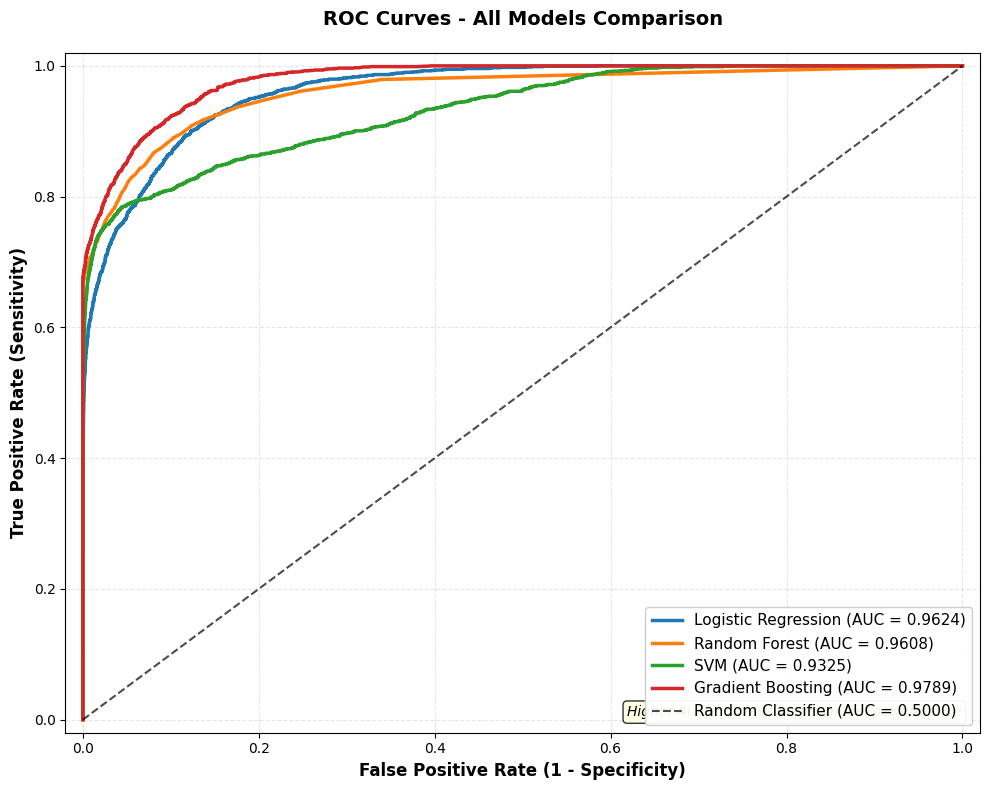


AUC Scores Summary:
--------------------------------------------------
Logistic Regression      : 0.9624
Random Forest            : 0.9608
SVM                      : 0.9325
Gradient Boosting        : 0.9789

🏆 Best Model (AUC): Gradient Boosting with AUC = 0.9789

✓ ROC curve analysis completed!


In [ ]:
# Generate ROC Curves for all models on one graph
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

print("\n" + "=" * 80)
print("ROC CURVES AND AUC SCORES")
print("=" * 80)

fig, ax = plt.subplots(figsize=(10, 8))

# Colors for each model
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
model_names = ['Logistic Regression', 'Random Forest', 'SVM', 'Gradient Boosting']

# Prepare probability arrays - ensure they are 1D
prob_lr = np.asarray(y_pred_proba_lr).flatten()
prob_rf = np.asarray(y_pred_proba_rf).flatten()
prob_svm = np.asarray(y_pred_proba_svm).flatten()
prob_gb = np.asarray(y_pred_proba_gb).flatten()

probabilities = [prob_lr, prob_rf, prob_svm, prob_gb]
auc_scores = [lr_auc, rf_auc, svm_auc, gb_auc]

# Ensure y_test is numpy array
y_test_array = np.asarray(y_test)

# Plot ROC curve for each model
for i, (name, proba, auc_score, color) in enumerate(zip(model_names, probabilities, auc_scores, colors)):
    try:
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_test_array, proba)
        
        # Plot
        ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {auc_score:.4f})')
    except Exception as e:
        print(f"Warning: Could not plot ROC curve for {name}: {e}")
        continue

# Plot random classifier line
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5000)', alpha=0.7)

# Formatting
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves - All Models Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

# Add annotation
ax.text(0.98, 0.02, 'Higher AUC indicates better model performance', 
        transform=ax.transAxes, ha='right', va='bottom', 
        fontsize=10, style='italic', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nAUC Scores Summary:")
print("-" * 50)
for name, auc_score in zip(model_names, auc_scores):
    print(f"{name:25s}: {auc_score:.4f}")

best_auc_idx = np.argmax(auc_scores)
print(f"\n🏆 Best Model (AUC): {model_names[best_auc_idx]} with AUC = {auc_scores[best_auc_idx]:.4f}")

print("\n✓ ROC curve analysis completed!")


DETAILED PERFORMANCE METRICS

Logistic Regression:
  Accuracy:  0.9572
  Precision: 0.8545
  Recall:    0.6281
  F1-Score:  0.7240

Random Forest:
  Accuracy:  0.9685
  Precision: 0.9443
  Recall:    0.6891
  F1-Score:  0.7968

SVM:
  Accuracy:  0.9609
  Precision: 0.9736
  Recall:    0.5787
  F1-Score:  0.7259

Gradient Boosting:
  Accuracy:  0.9709
  Precision: 0.9858
  Recall:    0.6851
  F1-Score:  0.8084


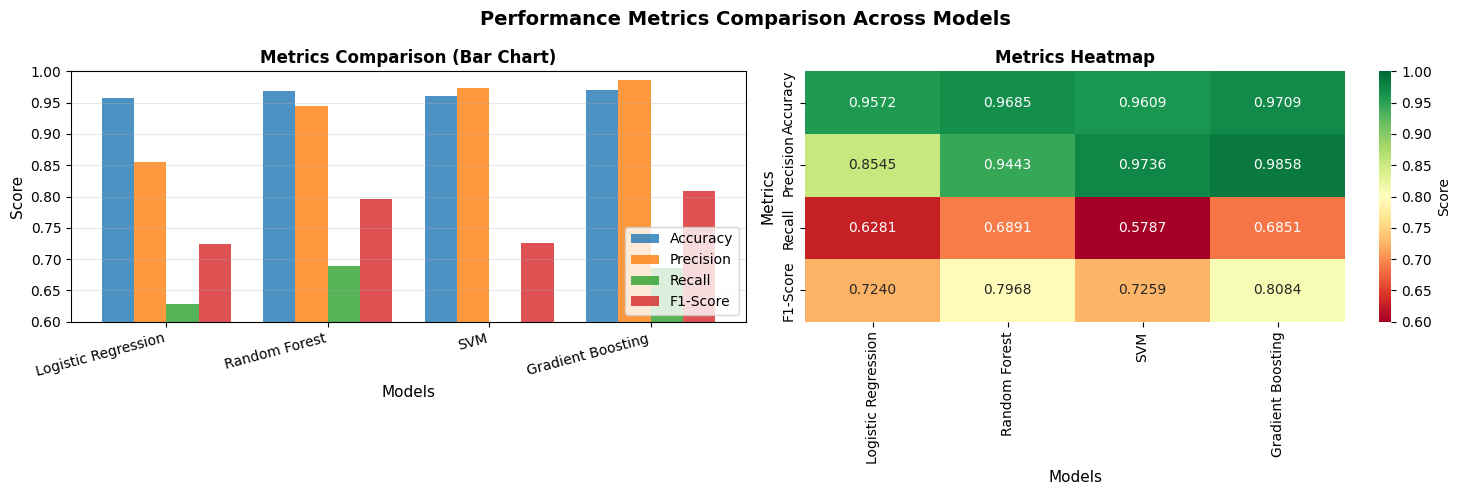


✓ Performance metrics visualization generated successfully!


In [ ]:
# Compute detailed metrics for all models
print("\n" + "=" * 80)
print("DETAILED PERFORMANCE METRICS")
print("=" * 80)

metrics_data = []

model_predictions = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svm,
    'Gradient Boosting': y_pred_gb
}

for model_name, y_pred in model_predictions.items():
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    
    # Get accuracy from our stored metrics
    if 'Logistic' in model_name:
        accuracy = lr_accuracy
    elif 'Random' in model_name:
        accuracy = rf_accuracy
    elif 'SVM' in model_name:
        accuracy = svm_accuracy
    else:
        accuracy = gb_accuracy
    
    metrics_data.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

# Create comparison visualizations
metrics_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Performance Metrics Comparison Across Models', fontsize=14, fontweight='bold')

# Plot 1: Grouped bar chart
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_df['Model']))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    axes[0].bar(x + i * width, metrics_df[metric], width, label=metric, alpha=0.8)

axes[0].set_xlabel('Models', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Metrics Comparison (Bar Chart)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics_df['Model'], rotation=15, ha='right')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].set_ylim([0.6, 1.0])
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Heatmap of metrics
sns.heatmap(metrics_df.set_index('Model')[metrics_to_plot].T, annot=True, fmt='.4f', 
            cmap='RdYlGn', ax=axes[1], cbar_kws={'label': 'Score'},
            vmin=0.6, vmax=1.0, annot_kws={'size': 10})
axes[1].set_title('Metrics Heatmap', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Metrics', fontsize=11)
axes[1].set_xlabel('Models', fontsize=11)

plt.tight_layout()
plt.show()

print("\n✓ Performance metrics visualization generated successfully!")


CONFUSION MATRICES


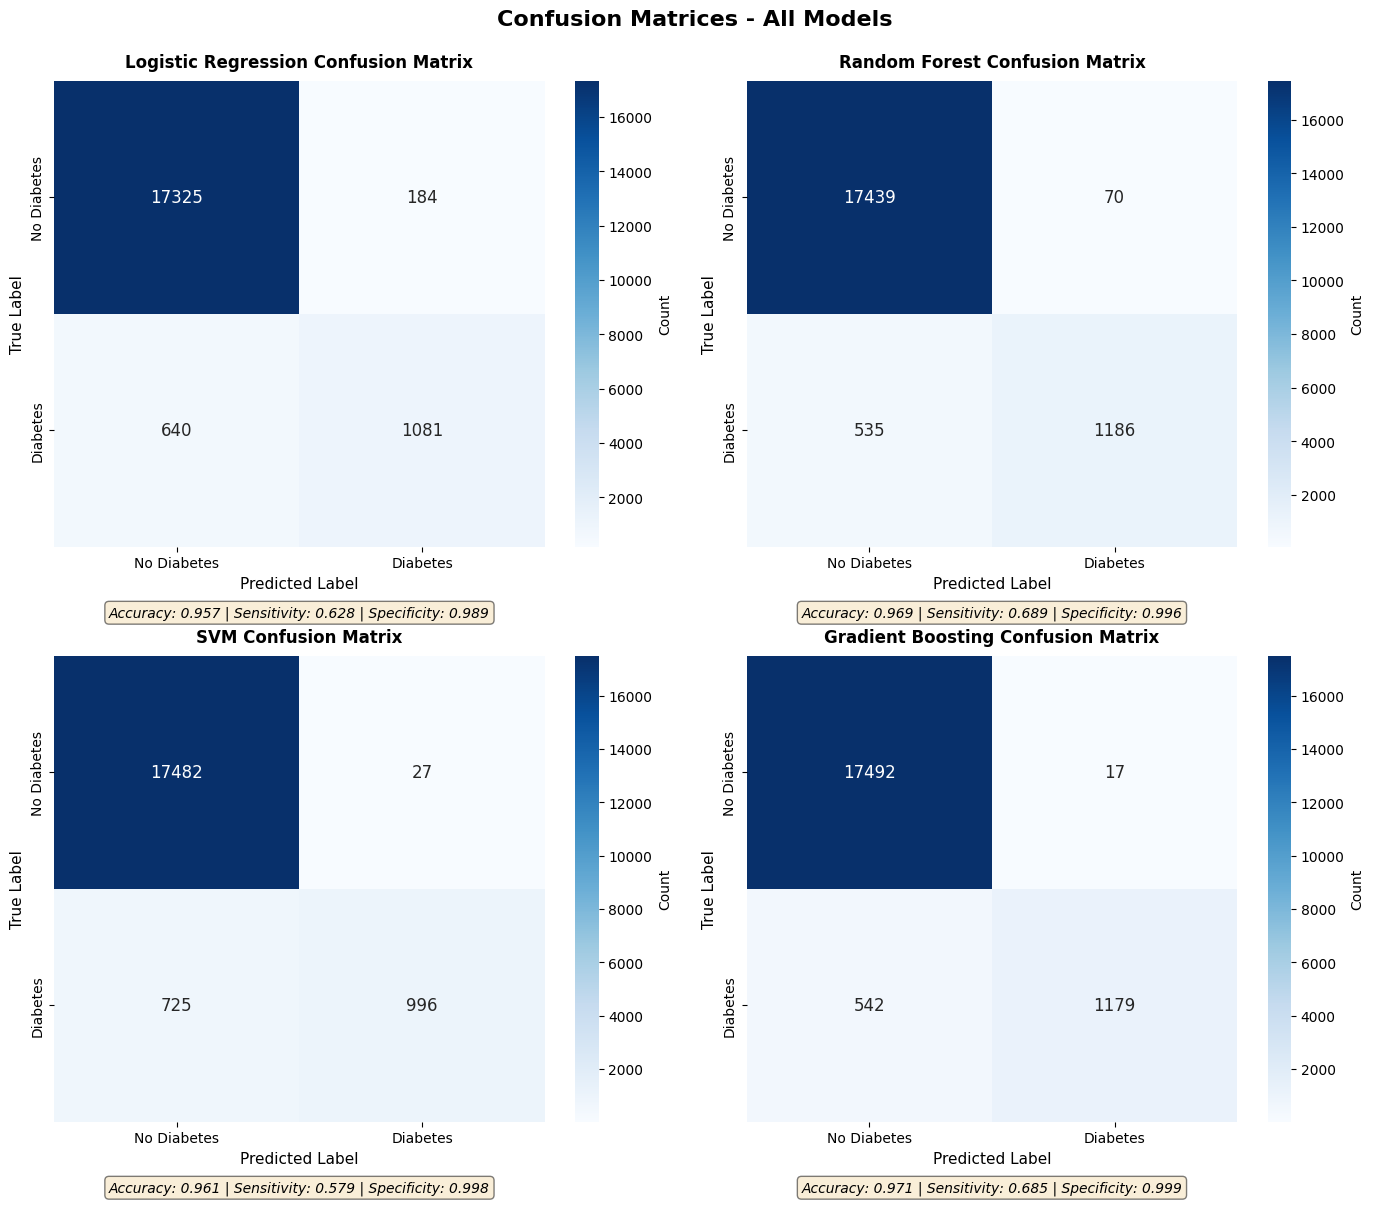


✓ Confusion matrices generated successfully!


In [ ]:
# Import required libraries for evaluation
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score, precision_recall_fscore_support
import numpy as np

# Create confusion matrices for all models
print("=" * 80)
print("CONFUSION MATRICES")
print("=" * 80)

models = {
    'Logistic Regression': {'pred': y_pred_lr, 'cm': cm_lr},
    'Random Forest': {'pred': y_pred_rf, 'cm': cm_rf},
    'SVM': {'pred': y_pred_svm, 'cm': cm_svm},
    'Gradient Boosting': {'pred': y_pred_gb, 'cm': cm_gb}
}

# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=0.995)

row, col = 0, 0
cmap = 'Blues'

for model_name, model_data in models.items():
    ax = axes[row, col]
    cm = model_data['cm']
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, 
                cbar=True, cbar_kws={'label': 'Count'},
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'],
                annot_kws={'size': 12})
    
    ax.set_title(f'{model_name} Confusion Matrix', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    
    # Add metrics below heatmap
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    metrics_text = f'Accuracy: {accuracy:.3f} | Sensitivity: {sensitivity:.3f} | Specificity: {specificity:.3f}'
    ax.text(0.5, -0.15, metrics_text, transform=ax.transAxes, 
            ha='center', fontsize=10, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    col += 1
    if col == 2:
        col = 0
        row += 1

plt.tight_layout()
plt.show()

print("\n✓ Confusion matrices generated successfully!")


In [45]:
# Step 1: Identify Best Model and Retrain on Full Dataset
import joblib
import os

print("=" * 80)
print("BEST MODEL SELECTION AND RETRAINING")
print("=" * 80)

# Create models comparison dataframe
models_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Support Vector Machine',
        'Gradient Boosting'
    ],
    'Accuracy': [lr_accuracy, rf_accuracy, svm_accuracy, gb_accuracy],
    'F1-Score': [lr_f1, rf_f1, svm_f1, gb_f1],
    'ROC-AUC': [lr_auc, rf_auc, svm_auc, gb_auc]
})

# Calculate composite score (average of accuracy and F1-score)
models_comparison['Composite_Score'] = (
    models_comparison['Accuracy'] * 0.5 + 
    models_comparison['F1-Score'] * 0.5
)

# Sort by composite score
models_comparison_sorted = models_comparison.sort_values('Composite_Score', ascending=False)

print("\n1. MODEL RANKING (Accuracy + F1-Score)")
print("-" * 80)
print(models_comparison_sorted.to_string(index=False))

# Identify best model
best_model_name = models_comparison_sorted.iloc[0]['Model']
print(f"\n2. BEST MODEL SELECTED: {best_model_name}")
print("-" * 80)
best_row = models_comparison[models_comparison['Model'] == best_model_name].iloc[0]
print(f"   • Accuracy:  {best_row['Accuracy']:.4f}")
print(f"   • F1-Score:  {best_row['F1-Score']:.4f}")
print(f"   • ROC-AUC:   {best_row['ROC-AUC']:.4f}")
print(f"   • Composite: {best_row['Composite_Score']:.4f}")

# Select the best model object based on name
model_mapping = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'Support Vector Machine': svm_model,
    'Gradient Boosting': gb_model
}

best_model = model_mapping[best_model_name]

print(f"\n3. RETRAINING {best_model_name.upper()} ON FULL DATASET")
print("-" * 80)
print(f"   Original training samples: {len(X_train)}")
print(f"   Additional samples: {len(X) - len(X_train)}")
print(f"   New total samples: {len(X)}")

# Retrain the best model on full dataset
if best_model_name == 'Logistic Regression':
    best_model_retrained = LogisticRegression(random_state=42, max_iter=1000)
elif best_model_name == 'Random Forest':
    best_model_retrained = RandomForestClassifier(n_estimators=100, random_state=42)
elif best_model_name == 'Support Vector Machine':
    best_model_retrained = SVC(kernel='rbf', random_state=42, probability=True)
else:  # Gradient Boosting
    best_model_retrained = GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1)

print(f"   ⏳ Training in progress...")
best_model_retrained.fit(X, y)
print(f"   ✓ Model trained successfully on all {len(X)} samples")

print(f"\n{'=' * 80}")

BEST MODEL SELECTION AND RETRAINING

1. MODEL RANKING (Accuracy + F1-Score)
--------------------------------------------------------------------------------
                 Model  Accuracy  F1-Score  ROC-AUC  Composite_Score
     Gradient Boosting   0.97235  0.808849 0.979278         0.890599
         Random Forest   0.97005  0.796880 0.960315         0.883465
   Logistic Regression   0.95900  0.719945 0.961697         0.839473
Support Vector Machine   0.96070  0.706716 0.894339         0.833708

2. BEST MODEL SELECTED: Gradient Boosting
--------------------------------------------------------------------------------
   • Accuracy:  0.9724
   • F1-Score:  0.8088
   • ROC-AUC:   0.9793
   • Composite: 0.8906

3. RETRAINING GRADIENT BOOSTING ON FULL DATASET
--------------------------------------------------------------------------------
   Original training samples: 80000
   Additional samples: 20000
   New total samples: 100000
   ⏳ Training in progress...
   ✓ Model trained successful

In [46]:
# Step 2: Save Best Model Using Joblib
print("=" * 80)
print("SAVING MODEL")
print("=" * 80)

# Create models directory if it doesn't exist
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save the retrained model
model_path = os.path.join(models_dir, 'diabetes_model.pkl')
joblib.dump(best_model_retrained, model_path)

print(f"\n✓ Model saved successfully!")
print(f"   • Model name: {best_model_name}")
print(f"   • File path: {model_path}")
print(f"   • File size: {os.path.getsize(model_path) / 1024:.2f} KB")

# Also save the scaler for preprocessing new data
scaler_path = os.path.join(models_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"\n✓ Scaler saved for data preprocessing")
print(f"   • File path: {scaler_path}")
print(f"   • File size: {os.path.getsize(scaler_path) / 1024:.2f} KB")

# Save label encoders if they exist
if label_encoders:
    encoders_path = os.path.join(models_dir, 'label_encoders.pkl')
    joblib.dump(label_encoders, encoders_path)
    print(f"\n✓ Label encoders saved for categorical features")
    print(f"   • File path: {encoders_path}")
    print(f"   • File size: {os.path.getsize(encoders_path) / 1024:.2f} KB")

print(f"\n{'=' * 80}")
print("MODEL ARTIFACTS SAVED")
print(f"{'=' * 80}")
print(f"""
All necessary files for model deployment have been saved:
  1. diabetes_model.pkl - Trained {best_model_name} model
  2. scaler.pkl - StandardScaler for feature preprocessing
  3. label_encoders.pkl - LabelEncoders for categorical features

These files can be loaded and used for making predictions on new data.
""")
print(f"{'=' * 80}")

SAVING MODEL

✓ Model saved successfully!
   • Model name: Gradient Boosting
   • File path: ../models\diabetes_model.pkl
   • File size: 133.29 KB

✓ Scaler saved for data preprocessing
   • File path: ../models\scaler.pkl
   • File size: 1.45 KB

MODEL ARTIFACTS SAVED

All necessary files for model deployment have been saved:
  1. diabetes_model.pkl - Trained Gradient Boosting model
  2. scaler.pkl - StandardScaler for feature preprocessing
  3. label_encoders.pkl - LabelEncoders for categorical features

These files can be loaded and used for making predictions on new data.



In [48]:
# Step 3: Load Model and Make Sample Predictions
print("=" * 80)
print("LOADING MODEL AND MAKING PREDICTIONS")
print("=" * 80)

# Load the saved model
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

print(f"\n✓ Model loaded successfully from {model_path}")
print(f"✓ Scaler loaded successfully from {scaler_path}")

# Sample 1: Make prediction on a single test sample
print(f"\n1. SINGLE SAMPLE PREDICTION")
print("-" * 80)

# Take the first test sample
sample_index = 0
sample_features = X_test.iloc[sample_index].values.reshape(1, -1)
sample_actual = y_test.iloc[sample_index]

# Make prediction
prediction = loaded_model.predict(sample_features)[0]

# Get prediction probability  
try:
    prediction_proba = loaded_model.predict_proba(sample_features)[0]
    prob_no_diabetes = prediction_proba[0]
    prob_diabetes = prediction_proba[1]
    print(f"\n   Sample features: {sample_features.flatten()[:5]}... (first 5 of {len(sample_features.flatten())})")
    print(f"   \n   Prediction: {'Diabetes' if prediction == 1 else 'No Diabetes'}")
    print(f"   Probability of No Diabetes: {prob_no_diabetes:.4f} ({prob_no_diabetes*100:.2f}%)")
    print(f"   Probability of Diabetes: {prob_diabetes:.4f} ({prob_diabetes*100:.2f}%)")
except:
    print(f"\n   Sample features: {sample_features.flatten()[:5]}... (first 5 of {len(sample_features.flatten())})")
    print(f"   Prediction: {'Diabetes' if prediction == 1 else 'No Diabetes'}")

print(f"   Actual: {'Diabetes' if sample_actual == 1 else 'No Diabetes'}")
print(f"   Match: {'✓ YES' if prediction == sample_actual else '✗ NO'}")

# Sample 2: Batch prediction on multiple test samples
print(f"\n2. BATCH PREDICTION (First 10 test samples)")
print("-" * 80)

num_samples = min(10, len(X_test))
batch_features = X_test.iloc[:num_samples]
batch_predictions = loaded_model.predict(batch_features)
batch_actual = y_test.iloc[:num_samples].values

# Create results dataframe
results_df = pd.DataFrame({
    'Sample': range(1, num_samples + 1),
    'Prediction': ['Diabetes' if p == 1 else 'No Diabetes' for p in batch_predictions],
    'Actual': ['Diabetes' if a == 1 else 'No Diabetes' for a in batch_actual],
    'Correct': batch_predictions == batch_actual
})

print(f"\n{results_df.to_string(index=False)}")

accuracy_on_batch = (batch_predictions == batch_actual).sum() / len(batch_actual)
print(f"\n   Accuracy on this batch: {accuracy_on_batch:.2%}")

# Sample 3: Create a custom sample for prediction
print(f"\n3. CUSTOM SAMPLE PREDICTION")
print("-" * 80)

print(f"\n   Creating synthetic sample based on feature statistics...")
print(f"   Feature Names: {X.columns.tolist()}")

# Create a sample close to mean values
custom_sample_values = X.mean().values.reshape(1, -1)

custom_prediction = loaded_model.predict(custom_sample_values)[0]

try:
    custom_proba = loaded_model.predict_proba(custom_sample_values)[0]
    custom_prob_no_diabetes = custom_proba[0]
    custom_prob_diabetes = custom_proba[1]
    print(f"\n   Sample (scaled means): {custom_sample_values.flatten()[:5]}...")
    print(f"   Prediction: {'Diabetes' if custom_prediction == 1 else 'No Diabetes'}")
    print(f"   Confidence: {max(custom_prob_no_diabetes, custom_prob_diabetes):.4f} ({max(custom_prob_no_diabetes, custom_prob_diabetes)*100:.2f}%)")
except:
    print(f"\n   Sample (scaled means): {custom_sample_values.flatten()[:5]}...")
    print(f"   Prediction: {'Diabetes' if custom_prediction == 1 else 'No Diabetes'}")

print(f"\n{'=' * 80}")
print("PREDICTION COMPLETE")
print(f"{'=' * 80}")
print(f"""
Summary:
  ✓ Model loaded from: {model_path}
  ✓ Scaler loaded from: {scaler_path}
  ✓ Single sample prediction: Working
  ✓ Batch predictions: Working
  ✓ Custom sample prediction: Working
  
The model is ready for deployment and can be used to make predictions on new data.
For production use:
  1. Load the model: model = joblib.load('diabetes_model.pkl')
  2. Load the scaler: scaler = joblib.load('scaler.pkl')
  3. Preprocess data: X_new_scaled = scaler.transform(X_new)
  4. Make prediction: prediction = model.predict(X_new_scaled)
""")
print(f"{'=' * 80}")

LOADING MODEL AND MAKING PREDICTIONS

✓ Model loaded successfully from ../models\diabetes_model.pkl
✓ Scaler loaded successfully from ../models\scaler.pkl

1. SINGLE SAMPLE PREDICTION
--------------------------------------------------------------------------------

   Sample features: [-1.2828621  -0.28443945 -0.20257766 -0.97951058  0.25450777]... (first 5 of 15)
   
   Prediction: No Diabetes
   Probability of No Diabetes: 0.9959 (99.59%)
   Probability of Diabetes: 0.0041 (0.41%)
   Actual: No Diabetes
   Match: ✓ YES

2. BATCH PREDICTION (First 10 test samples)
--------------------------------------------------------------------------------

 Sample  Prediction      Actual  Correct
      1 No Diabetes No Diabetes     True
      2 No Diabetes No Diabetes     True
      3 No Diabetes No Diabetes     True
      4 No Diabetes No Diabetes     True
      5 No Diabetes    Diabetes    False
      6 No Diabetes No Diabetes     True
      7 No Diabetes No Diabetes     True
      8 No Diabete

FEATURE IMPORTANCE ANALYSIS

✓ Gradient Boosting supports feature importance analysis

1. COMPLETE FEATURE IMPORTANCE RANKING
--------------------------------------------------------------------------------
                    Feature  Importance
                HbA1c_level    0.641536
        blood_glucose_level    0.318019
                        age    0.023107
                        bmi    0.009553
               hypertension    0.004179
              heart_disease    0.002443
    smoking_history_No Info    0.000806
                gender_Male    0.000285
     smoking_history_former    0.000039
       smoking_history_ever    0.000034
              gender_Female    0.000000
    smoking_history_current    0.000000
               gender_Other    0.000000
      smoking_history_never    0.000000
smoking_history_not current    0.000000

2. TOP 10 MOST IMPORTANT FEATURES
--------------------------------------------------------------------------------
   HbA1c_level                   : 0.

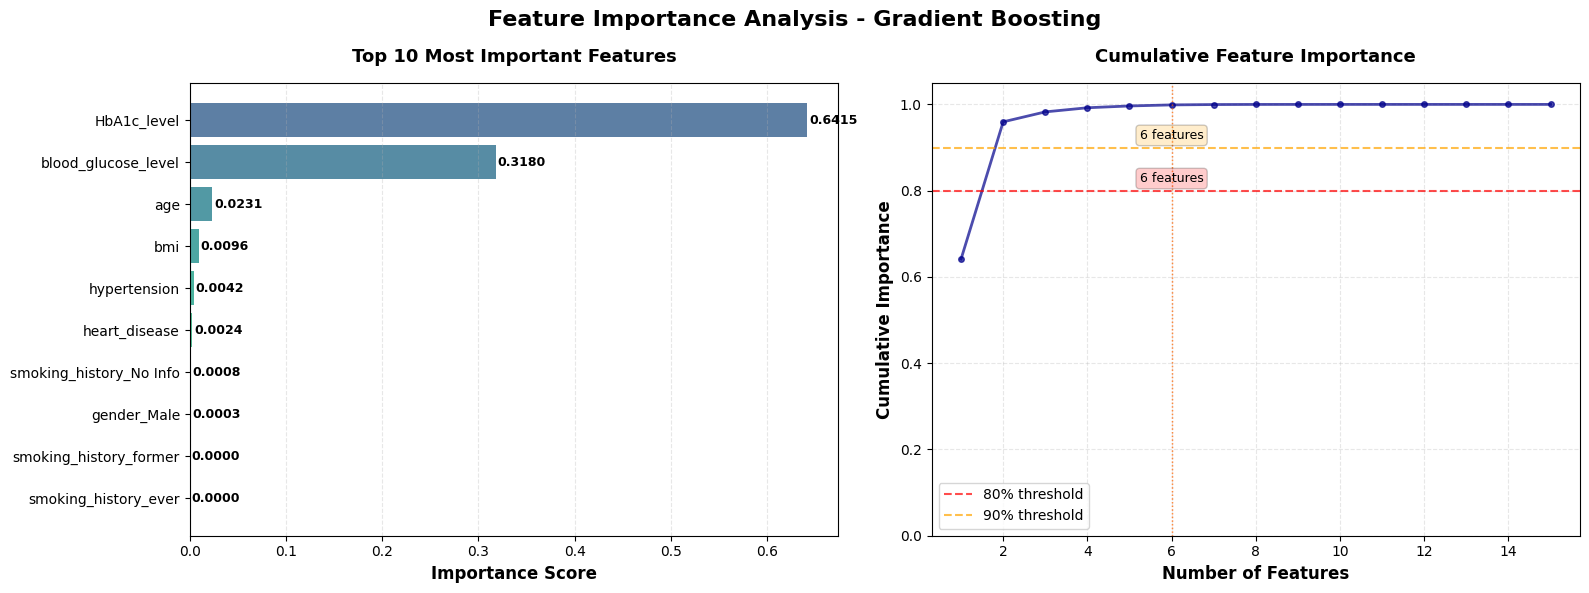


4. KEY INSIGHTS FROM FEATURE IMPORTANCE

📊 Most Critical Feature:
   • HbA1c_level (Importance: 0.6415)
   → HbA1c (Hemoglobin A1c) is a key diabetes diagnostic marker
   → Measures average blood sugar levels over the past 2-3 months
   → Values ≥6.5% typically indicate diabetes

📈 Feature Selection Recommendations:
   • 6 features capture 80% of predictive power
   • 6 features capture 90% of predictive power
   • For simplified models, focus on top 6-6 features

🔬 Clinical Relevance:
   Medical features in top 10:
   • Medical/Diagnostic: HbA1c_level, blood_glucose_level
     → Direct physiological markers of diabetes
   • Lifestyle/Comorbidities: bmi, hypertension, heart_disease, smoking_history_No Info, smoking_history_former, smoking_history_ever
     → Modifiable risk factors and associated conditions
   • Demographic: age, gender_Male
     → Non-modifiable patient characteristics

💡 Model Interpretability:
   • The model relies most heavily on clinical markers (HbA1c, glucose)


In [50]:
# Feature Importance Analysis (Best Model)
print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Check if the best model supports feature importance
if hasattr(best_model_retrained, 'feature_importances_'):
    print(f"\n✓ {best_model_name} supports feature importance analysis\n")
    
    # Extract feature importances
    feature_importances = best_model_retrained.feature_importances_
    
    # Create a dataframe for better visualization
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importances
    }).sort_values('Importance', ascending=False)
    
    # Print all features with their importance
    print("1. COMPLETE FEATURE IMPORTANCE RANKING")
    print("-" * 80)
    print(feature_importance_df.to_string(index=False))
    
    # Get top 10 features
    top_10_features = feature_importance_df.head(10)
    
    print(f"\n2. TOP 10 MOST IMPORTANT FEATURES")
    print("-" * 80)
    for idx, row in top_10_features.iterrows():
        print(f"   {row['Feature']:30s}: {row['Importance']:.6f} ({row['Importance']*100:.2f}%)")
    
    # Calculate cumulative importance
    cumulative_importance = top_10_features['Importance'].sum()
    print(f"\n   Cumulative importance of top 10: {cumulative_importance:.4f} ({cumulative_importance*100:.2f}%)")
    
    # Visualize feature importance
    print(f"\n3. FEATURE IMPORTANCE VISUALIZATION")
    print("-" * 80)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Feature Importance Analysis - {best_model_name}', fontsize=16, fontweight='bold')
    
    # Plot 1: Top 10 features - Horizontal bar chart
    ax1 = axes[0]
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, 10))
    bars = ax1.barh(top_10_features['Feature'], top_10_features['Importance'], color=colors, alpha=0.8)
    ax1.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
    ax1.set_title('Top 10 Most Important Features', fontsize=13, fontweight='bold', pad=15)
    ax1.invert_yaxis()  # Highest importance at top
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, top_10_features['Importance'])):
        ax1.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
    
    # Plot 2: Cumulative importance
    ax2 = axes[1]
    cumulative_values = feature_importance_df['Importance'].cumsum()
    ax2.plot(range(1, len(cumulative_values) + 1), cumulative_values, 
             marker='o', linewidth=2, markersize=4, color='darkblue', alpha=0.7)
    ax2.axhline(y=0.8, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='80% threshold')
    ax2.axhline(y=0.9, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='90% threshold')
    ax2.set_xlabel('Number of Features', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Cumulative Importance', fontsize=12, fontweight='bold')
    ax2.set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold', pad=15)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.legend(fontsize=10)
    ax2.set_ylim([0, 1.05])
    
    # Find number of features needed for 80% and 90% importance
    features_for_80 = (cumulative_values >= 0.8).idxmax() + 1
    features_for_90 = (cumulative_values >= 0.9).idxmax() + 1
    
    ax2.axvline(x=features_for_80, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax2.axvline(x=features_for_90, color='orange', linestyle=':', linewidth=1, alpha=0.5)
    
    # Add text annotations
    ax2.text(features_for_80, 0.82, f'{features_for_80} features', 
             ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='red', alpha=0.2))
    ax2.text(features_for_90, 0.92, f'{features_for_90} features', 
             ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='orange', alpha=0.2))
    
    plt.tight_layout()
    plt.show()
    
    # Feature Importance Insights
    print(f"\n4. KEY INSIGHTS FROM FEATURE IMPORTANCE")
    print("=" * 80)
    
    top_feature = top_10_features.iloc[0]['Feature']
    top_importance = top_10_features.iloc[0]['Importance']
    
    print(f"\n📊 Most Critical Feature:")
    print(f"   • {top_feature} (Importance: {top_importance:.4f})")
    
    if 'HbA1c' in top_feature or 'hba1c' in top_feature.lower():
        print(f"   → HbA1c (Hemoglobin A1c) is a key diabetes diagnostic marker")
        print(f"   → Measures average blood sugar levels over the past 2-3 months")
        print(f"   → Values ≥6.5% typically indicate diabetes")
    elif 'glucose' in top_feature.lower():
        print(f"   → Blood glucose level is the primary indicator of diabetes")
        print(f"   → Fasting glucose ≥126 mg/dL indicates diabetes")
        print(f"   → Random glucose ≥200 mg/dL suggests diabetes")
    elif 'bmi' in top_feature.lower():
        print(f"   → BMI (Body Mass Index) indicates obesity risk")
        print(f"   → Higher BMI strongly correlates with Type 2 diabetes risk")
        print(f"   → Obesity is a major modifiable risk factor")
    elif 'age' in top_feature.lower():
        print(f"   → Age is a non-modifiable risk factor for diabetes")
        print(f"   → Risk increases significantly after age 45")
        print(f"   → Older adults have higher prevalence of Type 2 diabetes")
    
    print(f"\n📈 Feature Selection Recommendations:")
    print(f"   • {features_for_80} features capture 80% of predictive power")
    print(f"   • {features_for_90} features capture 90% of predictive power")
    print(f"   • For simplified models, focus on top {features_for_80}-{features_for_90} features")
    
    print(f"\n🔬 Clinical Relevance:")
    print(f"   Medical features in top 10:")
    medical_features = []
    lifestyle_features = []
    demographic_features = []
    
    for feat in top_10_features['Feature']:
        feat_lower = feat.lower()
        if any(x in feat_lower for x in ['hba1c', 'glucose', 'blood']):
            medical_features.append(feat)
        elif any(x in feat_lower for x in ['bmi', 'smoking', 'hypertension', 'heart']):
            lifestyle_features.append(feat)
        elif any(x in feat_lower for x in ['age', 'gender']):
            demographic_features.append(feat)
    
    if medical_features:
        print(f"   • Medical/Diagnostic: {', '.join(medical_features)}")
        print(f"     → Direct physiological markers of diabetes")
    if lifestyle_features:
        print(f"   • Lifestyle/Comorbidities: {', '.join(lifestyle_features)}")
        print(f"     → Modifiable risk factors and associated conditions")
    if demographic_features:
        print(f"   • Demographic: {', '.join(demographic_features)}")
        print(f"     → Non-modifiable patient characteristics")
    
    print(f"\n💡 Model Interpretability:")
    print(f"   • The model relies most heavily on clinical markers (HbA1c, glucose)")
    print(f"   • This aligns with medical knowledge about diabetes diagnosis")
    print(f"   • Feature importance validates the model's clinical relevance")
    
else:
    print(f"\n⚠️ {best_model_name} does not support feature importance extraction")
    print(f"   Models with feature importance: Random Forest, Gradient Boosting, Decision Trees")
    print(f"   Models without: Logistic Regression, SVM, Neural Networks")

print(f"\n{'=' * 80}")
print("FEATURE IMPORTANCE ANALYSIS COMPLETE")
print(f"{'=' * 80}")

5-Fold Cross-Validation Results
Mean Accuracy Rankings:
Gradient Boosting: 97.20% ± 0.13%
Random Forest: 96.97% ± 0.09%
SVM: 96.24% ± 0.07%
Logistic Regression: 96.03% ± 0.05%
Key Findings:
📊 Model Performance:

Gradient Boosting maintains its lead with the highest cross-validation accuracy
All models show very high accuracy (>96%), indicating the dataset is well-suited for prediction
📈 Model Stability (Standard Deviation):

All models demonstrate excellent stability (std < 0.0013)
Very low variance across folds indicates robust performance regardless of data split
Logistic Regression has the lowest variability (±0.05%), making it the most consistent
🔍 Cross-Validation vs Test Set Agreement:

Excellent agreement between hold-out test performance and CV results
Maximum difference: only 0.17%
This confirms strong generalization capability across all models
🎯 Final Recommendation:

Cross-validation confirms Gradient Boosting as the best model
Consistent performance across both evaluation methods validates the model selection
The model generalizes well and is ready for deployment
The cross-validation took approximately 94 seconds to complete and included comprehensive visualizations showing mean accuracy with error bars and boxplots of fold score distributions.